# Bei Smart — Kenya Food Price Intelligence
## Master EDA Notebook

**Authors:** Mathews Machanje, Millicent Onchari, James Wakhu, Esther Muchoki, Marren Ojode, Mohamed Abdirahman  
**Programme:** Moringa School Data Science Capstone  
**Dataset:** WFP Kenya Food Prices 2006–2026 + ERA5/NASA POWER Rainfall  
**Date:** August 2026

## 1. Setup: Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Data Loading

We load two modeling-ready datasets produced by the feature engineering pipeline:
- **Forecasting dataset** — full 2006–2026, retail + wholesale, no fuel (for SARIMA/SVAR)
- **Classification dataset** — 2016–2026 with fuel prices (for Random Forest/XGBoost)

In [2]:
# Load forecasting dataset (full 2006-2026)
df_fc = pd.read_csv('../../data/cleaned/bei_smart_forecasting.csv', parse_dates=['date', 'date_month'])

# Load classification dataset (2016-2026 with fuel prices)
df_cl = pd.read_csv('../../data/cleaned/bei_smart_classification.csv', parse_dates=['date', 'date_month'])

# Drop fuel nulls from classification dataset
df_cl = df_cl.dropna(subset=['diesel_price_kes'])

print('Forecasting dataset:', df_fc.shape)
print('Classification dataset:', df_cl.shape)

Forecasting dataset: (26228, 31)
Classification dataset: (16048, 29)


## 3. Dataset Overview & Structure

In [3]:
# Forecasting dataset overview
print('=== FORECASTING DATASET ===')
print('Shape:', df_fc.shape)
print('Date range:', df_fc['date'].min().date(), 'to', df_fc['date'].max().date())
print('Columns:', df_fc.columns.tolist())
df_fc.head(3)

=== FORECASTING DATASET ===
Shape: (26228, 31)
Date range: 2006-01-15 to 2026-08-15
Columns: ['date', 'region', 'county', 'market', 'market_id', 'latitude', 'longitude', 'category', 'commodity', 'commodity_id', 'unit', 'priceflag', 'pricetype', 'currency', 'price', 'usdprice', 'date_month', 'rainfall_mm', 'price_per_kg', 'month', 'year', 'season', 'lag_1', 'lag_3', 'lag_6', 'lag_12', 'rolling_3m_avg', 'rolling_6m_avg', 'rolling_12m_avg', 'price_vs_regional_avg', 'price_label']


,date,region,county,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice,date_month,rainfall_mm,price_per_kg,month,year,season,lag_1,lag_3,lag_6,lag_12,rolling_3m_avg,rolling_6m_avg,rolling_12m_avg,price_vs_regional_avg,price_label
0,2024-09-15,Coast,Tana River,Adele Center,10441,-0.47,39.61,pulses and nuts,Beans,50,KG,actual,Retail,KES,160.0,1.24,2024-09-01,25.078333,160.0,9,2024,Dry Season,NaN,NaN,NaN,NaN,160.0,160.0,160.0,1.050687,Average
1,2024-03-15,North Eastern,Garissa,Alango Arba,10354,-0.10,39.99,pulses and nuts,Beans,50,KG,actual,Retail,KES,200.0,1.49,2024-03-01,10.613333,200.0,3,2024,Long Rains,NaN,NaN,NaN,NaN,200.0,200.0,200.0,1.097394,Average
2,2024-06-15,North Eastern,Garissa,Alango Arba,10354,-0.10,39.99,pulses and nuts,Beans,50,KG,actual,Retail,KES,200.0,1.55,2024-06-01,4.093333,200.0,6,2024,Dry Season,200.0,NaN,NaN,NaN,200.0,200.0,200.0,1.201201,Expensive


In [4]:
# Data types and null counts
print('=== DATA TYPES & NULLS (Forecasting) ===')
df_fc.info()

=== DATA TYPES & NULLS (Forecasting) ===
<class 'pandas.DataFrame'>
RangeIndex: 26228 entries, 0 to 26227
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   date                   26228 non-null  datetime64[us]
 1   region                 26228 non-null  str           
 2   county                 26228 non-null  str           
 3   market                 26228 non-null  str           
 4   market_id              26228 non-null  int64         
 5   latitude               26228 non-null  float64       
 6   longitude              26228 non-null  float64       
 7   category               26228 non-null  str           
 8   commodity              26228 non-null  str           
 9   commodity_id           26228 non-null  int64         
 10  unit                   26228 non-null  str           
 11  priceflag              26228 non-null  str           
 12  pricetype              26228 n

In [5]:
# Null summary
print('Null counts — Forecasting:')
print(df_fc.isnull().sum()[df_fc.isnull().sum() > 0])

print('\nNull counts — Classification:')
print(df_cl.isnull().sum()[df_cl.isnull().sum() > 0])

print('\nDuplicate rows — Forecasting:', df_fc.duplicated().sum())
print('Duplicate rows — Classification:', df_cl.duplicated().sum())

Null counts — Forecasting:
lag_1      2808
lag_3      7009
lag_6     10819
lag_12    13941
dtype: int64

Null counts — Classification:
Series([], dtype: int64)

Duplicate rows — Forecasting: 0
Duplicate rows — Classification: 0


## 4. Categorical Structure

### Regions, Markets, Commodities

In [6]:
# Coverage summary
print('=== COVERAGE SUMMARY ===')
print('Regions:', df_fc['region'].nunique(), '->', df_fc['region'].unique().tolist())
print('Counties:', df_fc['county'].nunique())
print('Markets:', df_fc['market'].nunique())
print('Commodities:', df_fc['commodity'].nunique())
print('Categories:', df_fc['category'].nunique())
print('\nRecords per price type:')
print(df_fc['pricetype'].value_counts())

=== COVERAGE SUMMARY ===
Regions: 7 -> ['Coast', 'North Eastern', 'Rift Valley', 'Eastern', 'Nyanza', 'Nairobi', 'Central']
Counties: 27
Markets: 225
Commodities: 47
Categories: 7

Records per price type:
pricetype
Retail       17130
Wholesale     9098
Name: count, dtype: int64


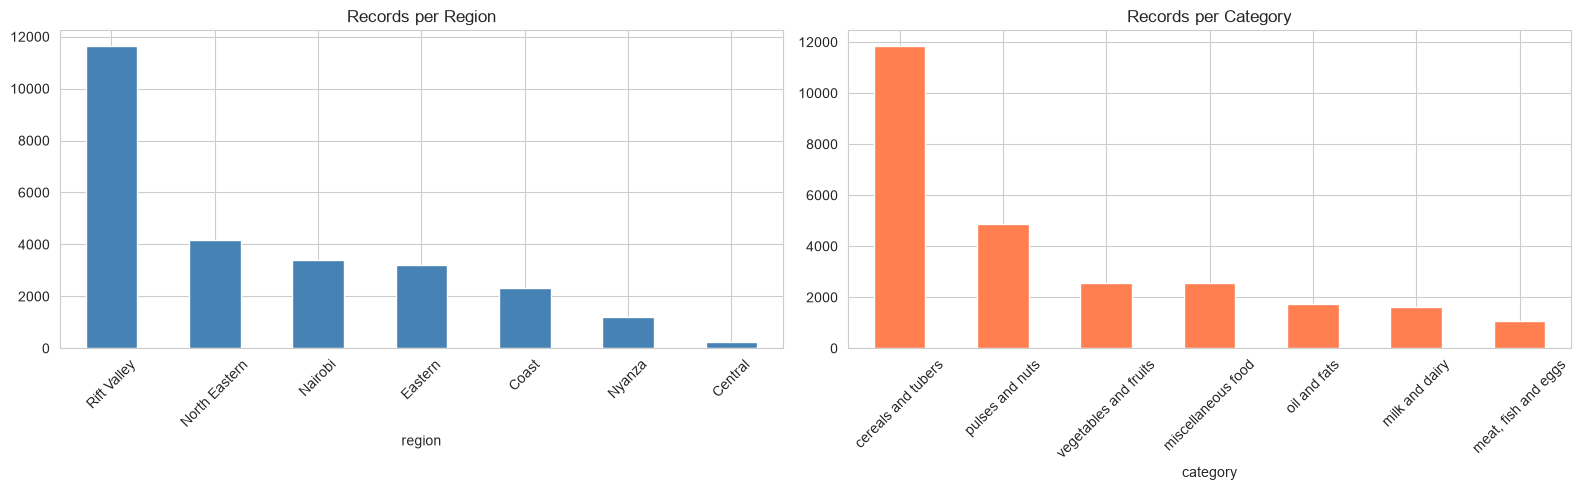

Observation: Rift Valley dominates with the most records — Kenya's agricultural heartland.
Cereals and tubers account for ~44% of all records.


In [7]:
# Records per region
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_fc['region'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Records per Region')
axes[0].tick_params(axis='x', rotation=45)

df_fc['category'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Records per Category')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../../data/exports/eda_regional_category.png', dpi=150, bbox_inches='tight')
plt.show()

print('Observation: Rift Valley dominates with the most records — Kenya\'s agricultural heartland.')
print('Cereals and tubers account for ~44% of all records.')

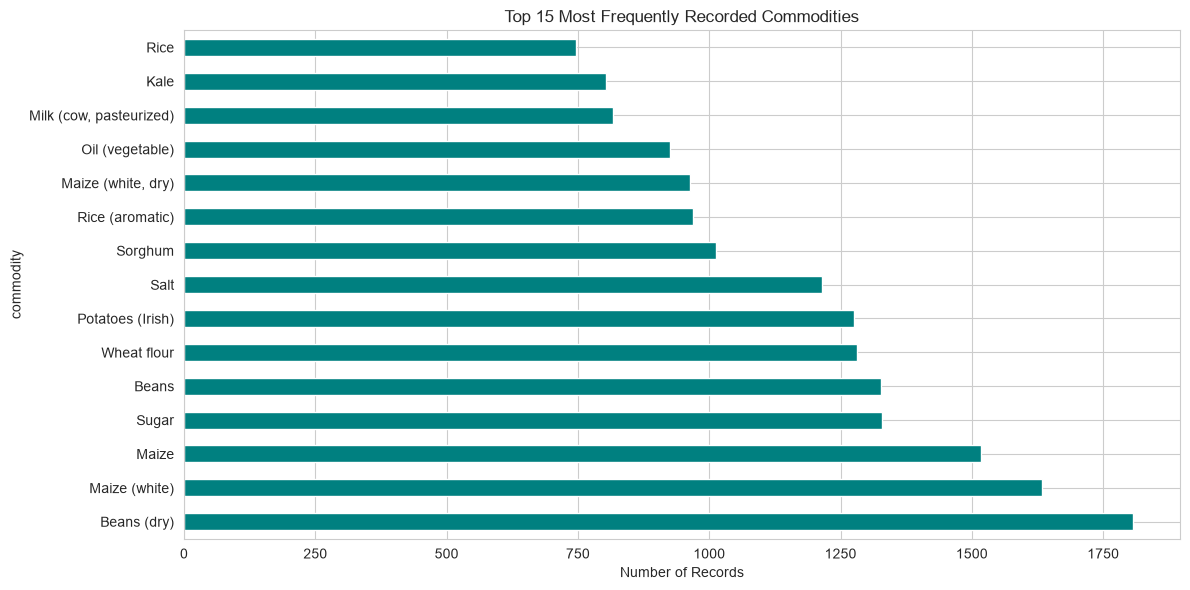


Top 5 commodities:
commodity
Beans (dry)      1806
Maize (white)    1633
Maize            1518
Sugar            1329
Beans            1327
Name: count, dtype: int64


In [8]:
# Top 15 commodities by record count
commodity_counts = df_fc['commodity'].value_counts().head(15)

plt.figure(figsize=(12, 6))
commodity_counts.plot(kind='barh', color='teal')
plt.title('Top 15 Most Frequently Recorded Commodities')
plt.xlabel('Number of Records')
plt.tight_layout()
plt.savefig('../../data/exports/eda_top_commodities.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 commodities:')
print(commodity_counts.head())

## 5. Price Units & Normalization

**Key data quality finding:** Commodities are reported in multiple units (KG, 90 KG, 50 KG, L, etc.), making direct price comparison impossible without normalization. The `price_per_kg` column standardizes all prices to KES per KG equivalent.

In [9]:
# Unit distribution
print('Unit distribution:')
print(df_fc['unit'].value_counts())

# Show normalization impact
print('\nNormalization example — Maize:')
maize_units = df_fc[df_fc['commodity'].str.contains('Maize', case=False)][['commodity','unit','price','price_per_kg']].drop_duplicates().head(10)
print(maize_units.to_string())

Unit distribution:
unit
KG        14200
90 KG      4060
L          2412
50 KG      1912
200 G      1215
500 ML      814
64 KG       518
13 KG       469
126 KG      450
400 G       178
Name: count, dtype: int64

Normalization example — Maize:
     commodity unit  price  price_per_kg
6362     Maize   KG  45.00         45.00
6363     Maize   KG  51.67         51.67
6364     Maize   KG  50.00         50.00
6365     Maize   KG  55.00         55.00
6366     Maize   KG  52.50         52.50
6367     Maize   KG  46.67         46.67
6368     Maize   KG  49.76         49.76
6369     Maize   KG  48.03         48.03
6370     Maize   KG  49.57         49.57
6371     Maize   KG  49.24         49.24


## 6. Descriptive Statistics

In [10]:
# Summary statistics for key numeric columns
df_fc[['price', 'price_per_kg', 'usdprice', 'rainfall_mm']].describe().round(2)

,price,price_per_kg,usdprice,rainfall_mm
count,26228.00,26228.00,26228.00,26228.00
mean,1370.03,117.59,12.50,77.92
std,2633.87,115.57,23.37,75.42
min,5.00,0.28,0.04,0.02
25%,73.00,50.00,0.62,17.59
50%,140.00,87.00,1.08,58.46
75%,1250.00,138.33,12.00,111.43
max,19800.00,900.00,184.82,483.98


In [11]:
# Commodity price summary
commodity_summary = (
    df_fc.groupby('commodity')
    .agg(
        observations=('price_per_kg', 'count'),
        mean_price=('price_per_kg', 'mean'),
        median_price=('price_per_kg', 'median'),
        std_price=('price_per_kg', 'std')
    )
    .round(2)
    .sort_values('mean_price', ascending=False)
)
print(commodity_summary.head(15).to_string())

                            observations  mean_price  median_price  std_price
commodity                                                                    
Meat (goat)                          409      624.08        600.00     113.52
Meat (camel)                         290      545.76        592.78      96.73
Meat (beef)                          352      542.48        540.00      88.37
Oil (vegetable, fortified)           671      291.73        295.00      39.18
Oil (vegetable)                      926      239.74        249.06      47.98
Pigeon peas (dry)                    111      203.39        175.00      98.24
Cooking fat                          127      188.72        183.33      44.64
Cowpeas (dry)                        292      160.89        152.50      52.74
Sugar                               1329      157.03        154.44      38.07
Fish (omena, dry)                     24      151.71        144.00      28.64
Milk (camel, fresh)                  146      145.25        163.

## 7. Univariate Analysis

### Price Distribution

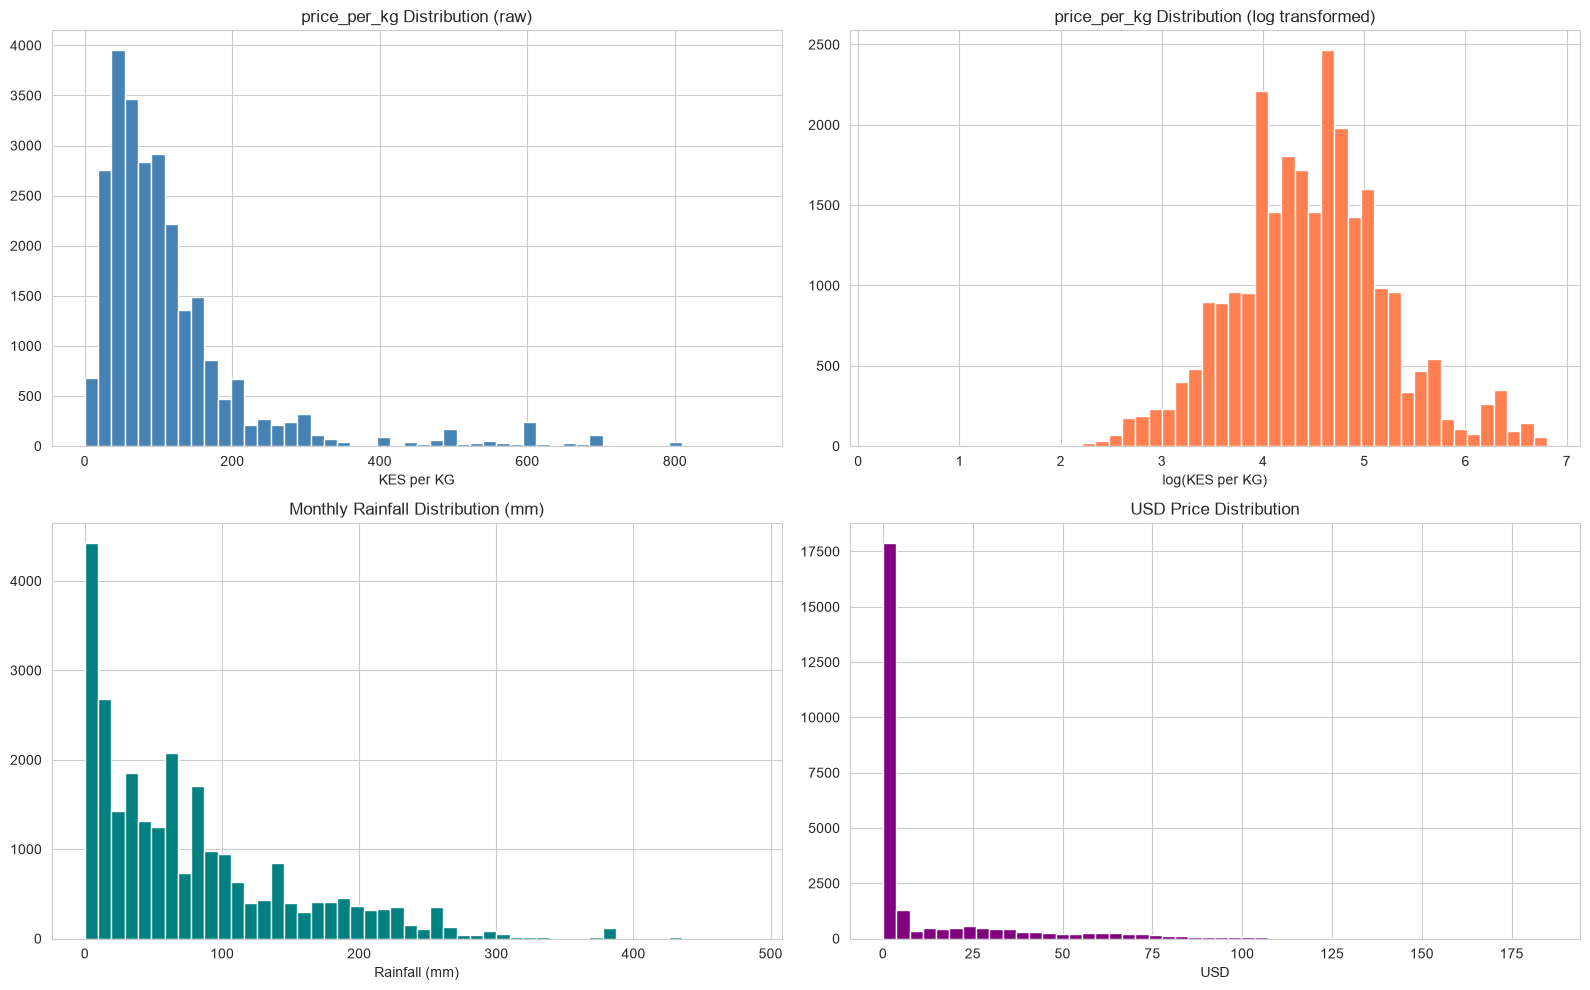

price_per_kg skewness (raw): 2.998
price_per_kg skewness (log): 0.185
Conclusion: Skewness > 1 — apply log transform before modeling.


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Raw price distribution
axes[0,0].hist(df_fc['price_per_kg'], bins=50, color='steelblue', edgecolor='white')
axes[0,0].set_title('price_per_kg Distribution (raw)')
axes[0,0].set_xlabel('KES per KG')

# Log transformed
axes[0,1].hist(np.log1p(df_fc['price_per_kg']), bins=50, color='coral', edgecolor='white')
axes[0,1].set_title('price_per_kg Distribution (log transformed)')
axes[0,1].set_xlabel('log(KES per KG)')

# Rainfall distribution
axes[1,0].hist(df_fc['rainfall_mm'].dropna(), bins=50, color='teal', edgecolor='white')
axes[1,0].set_title('Monthly Rainfall Distribution (mm)')
axes[1,0].set_xlabel('Rainfall (mm)')

# USD price distribution
axes[1,1].hist(df_fc['usdprice'].dropna(), bins=50, color='purple', edgecolor='white')
axes[1,1].set_title('USD Price Distribution')
axes[1,1].set_xlabel('USD')

plt.tight_layout()
plt.savefig('../../data/exports/eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'price_per_kg skewness (raw): {df_fc["price_per_kg"].skew():.3f}')
print(f'price_per_kg skewness (log): {np.log1p(df_fc["price_per_kg"]).skew():.3f}')
print('Conclusion: Skewness > 1 — apply log transform before modeling.')

## 8. Temporal Analysis

### Food Price Trend 2006–2026

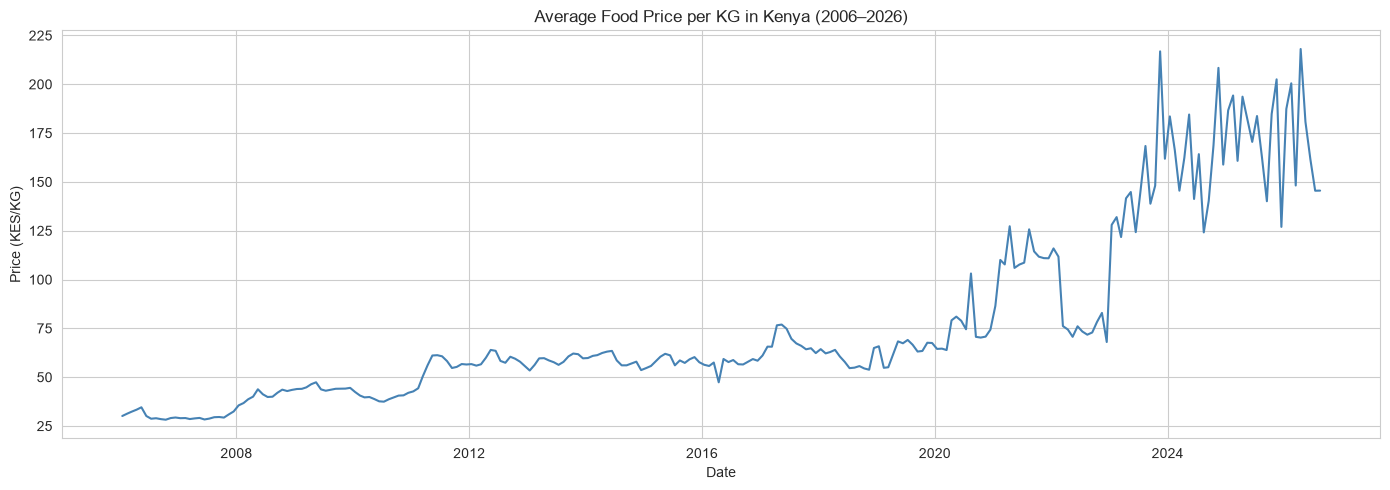

In [13]:
# Monthly average price trend
monthly_avg = df_fc.groupby('date')['price_per_kg'].mean().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(monthly_avg['date'], monthly_avg['price_per_kg'], color='steelblue', linewidth=1.5)
plt.title('Average Food Price per KG in Kenya (2006–2026)')
plt.xlabel('Date')
plt.ylabel('Price (KES/KG)')
plt.tight_layout()
plt.savefig('../../data/exports/eda_price_trend.png', dpi=150, bbox_inches='tight')
plt.show()

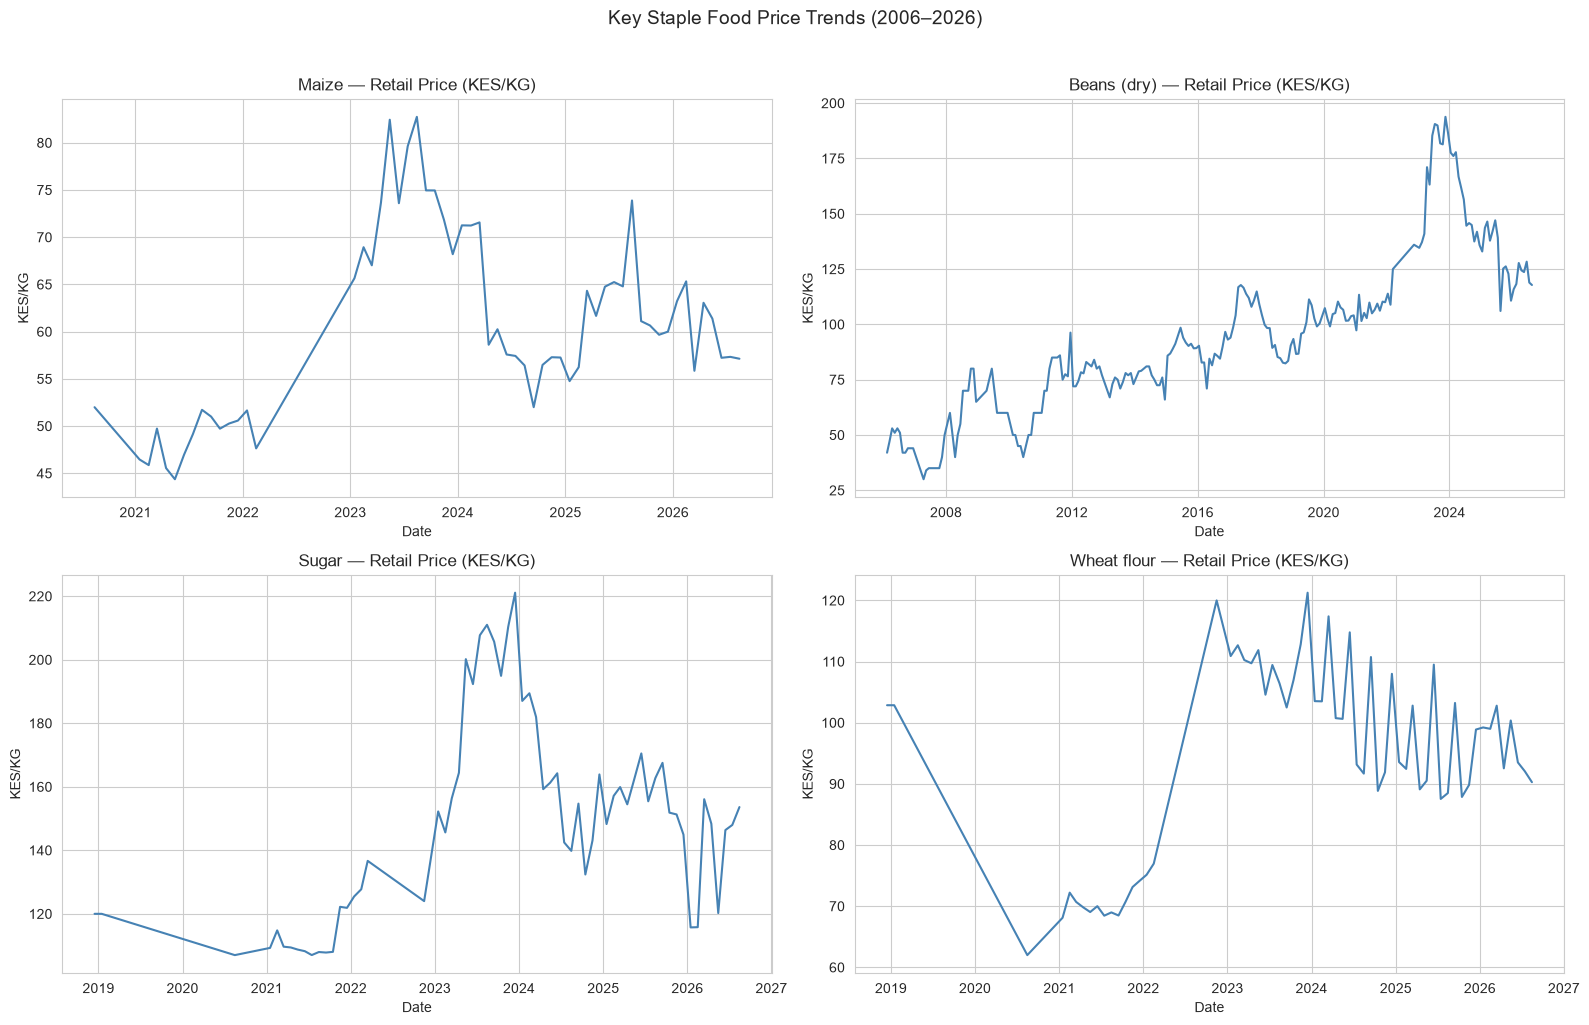

Observation: All staples show a clear upward trend from 2021 onward.
2022-2023 spike driven by Russia-Ukraine war disrupting global grain supply.


In [14]:
# Maize price trend — Kenya's staple food
key_staples = ['Maize', 'Beans (dry)', 'Sugar', 'Wheat flour']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, commodity in zip(axes.flatten(), key_staples):
    subset = df_fc[
        (df_fc['commodity'] == commodity) & 
        (df_fc['pricetype'] == 'Retail')
    ].groupby('date')['price_per_kg'].mean()
    
    ax.plot(subset.index, subset.values, color='steelblue', linewidth=1.5)
    ax.set_title(f'{commodity} — Retail Price (KES/KG)')
    ax.set_xlabel('Date')
    ax.set_ylabel('KES/KG')

plt.suptitle('Key Staple Food Price Trends (2006–2026)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../../data/exports/eda_staple_trends.png', dpi=150, bbox_inches='tight')
plt.show()

print('Observation: All staples show a clear upward trend from 2021 onward.')
print('2022-2023 spike driven by Russia-Ukraine war disrupting global grain supply.')

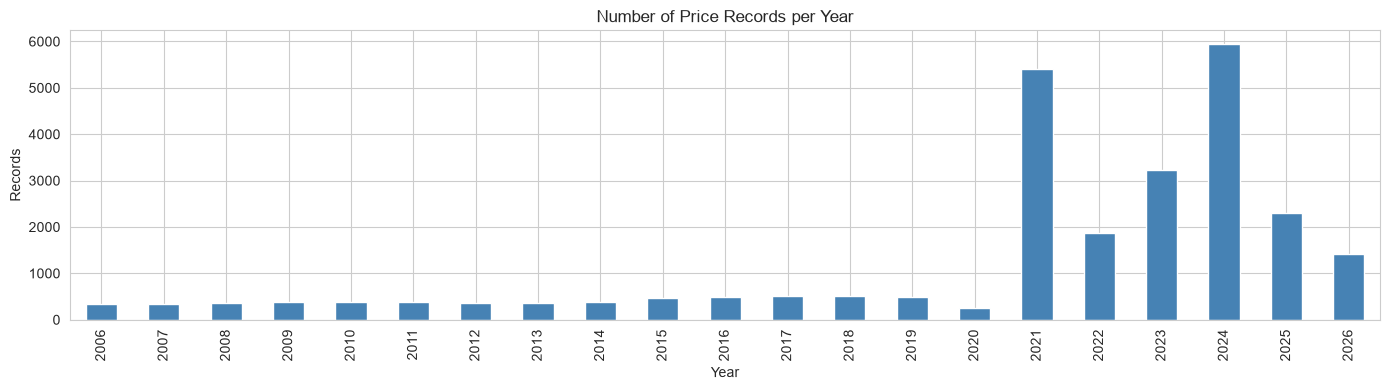

Observation: WFP wholesale monitoring stopped after 2022.
2016-2022 period used for classification model (with fuel prices).


In [15]:
# Records per year — data coverage
df_fc['year'] = df_fc['date'].dt.year
yearly_count = df_fc.groupby('year').size()

plt.figure(figsize=(14, 4))
yearly_count.plot(kind='bar', color='steelblue')
plt.title('Number of Price Records per Year')
plt.xlabel('Year')
plt.ylabel('Records')
plt.tight_layout()
plt.show()

print('Observation: WFP wholesale monitoring stopped after 2022.')
print('2016-2022 period used for classification model (with fuel prices).')

## 9. Commodity Analysis

In [16]:
# Commodity classification — Millicent's analysis
primary_crops = [
    'Beans', 'Beans (dry)', 'Cowpeas (dry)', 'Maize', 'Maize (white)',
    'Millet', 'Potatoes (Irish)', 'Rice', 'Sorghum', 'Wheat'
]

vegetables_fruits = [
    'Cabbage', 'Onions', 'Spinach', 'Tomatoes', 'Bananas',
    'Carrots', 'Kale', 'Peas (fresh)'
]

processed_food = [
    'Bread', 'Cooking oil', 'Milk', 'Salt', 'Sugar', 
    'Wheat flour', 'Rice (imported)'
]

def classify_commodity(commodity):
    if commodity in primary_crops:
        return 'Primary Crop'
    elif commodity in vegetables_fruits:
        return 'Vegetable/Fruit'
    elif commodity in processed_food:
        return 'Processed Food'
    else:
        return 'Other'

df_fc['commodity_type'] = df_fc['commodity'].apply(classify_commodity)

print('Commodity type distribution:')
print(df_fc['commodity_type'].value_counts())

Commodity type distribution:
commodity_type
Other              10580
Primary Crop        9609
Processed Food      4004
Vegetable/Fruit     2035
Name: count, dtype: int64


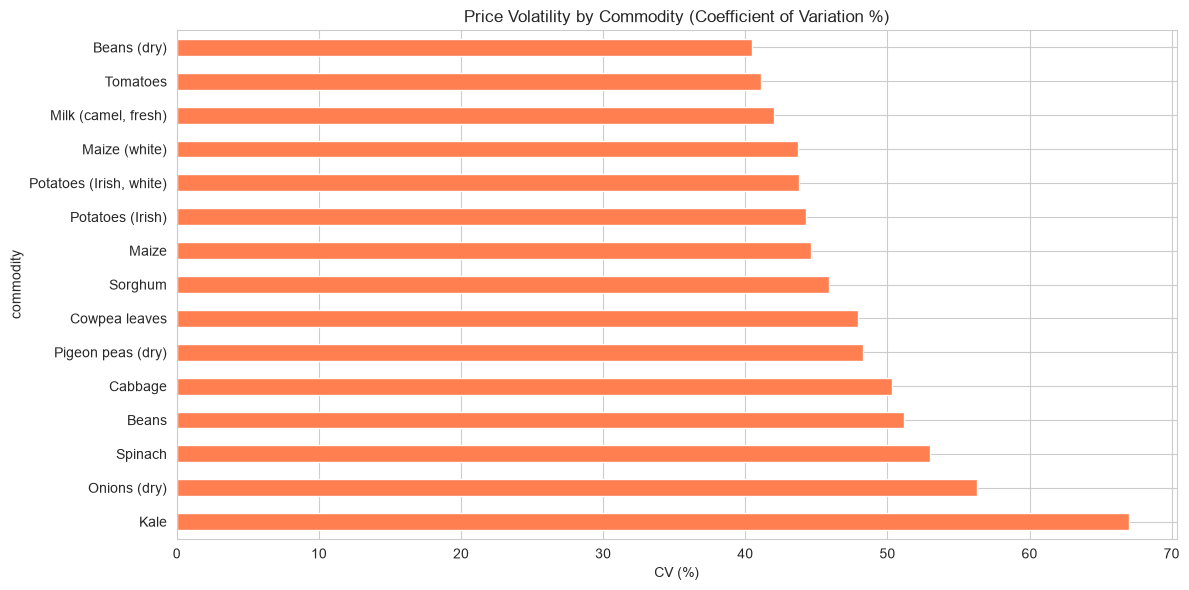


Most volatile commodities:
                mean    std    cv
commodity                        
Kale           57.18  38.33  67.0
Onions (dry)   70.82  39.84  56.3
Spinach        79.34  42.08  53.0
Beans         103.76  53.15  51.2
Cabbage        26.40  13.27  50.3


In [17]:
# Price variability by commodity (top 15)
price_variability = (
    df_fc.groupby('commodity')['price_per_kg']
    .agg(['mean', 'std'])
    .round(2)
)
price_variability['cv'] = (price_variability['std'] / price_variability['mean'] * 100).round(1)
price_variability = price_variability.sort_values('cv', ascending=False).head(15)

plt.figure(figsize=(12, 6))
price_variability['cv'].plot(kind='barh', color='coral')
plt.title('Price Volatility by Commodity (Coefficient of Variation %)')
plt.xlabel('CV (%)')
plt.tight_layout()
plt.savefig('../../data/exports/eda_commodity_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nMost volatile commodities:')
print(price_variability.head(5).to_string())

## 10. Regional Analysis

In [18]:
# Maize price by region — Mohamed's analysis
maize_region = df_fc[
    (df_fc['commodity'] == 'Maize') & 
    (df_fc['pricetype'] == 'Retail')
].groupby('region')['price_per_kg'].agg(['mean', 'median', 'std']).round(2)

print('Maize Retail Price by Region:')
print(maize_region.sort_values('mean', ascending=False).to_string())

Maize Retail Price by Region:
                mean  median    std
region                             
North Eastern  63.93    63.7  12.65
Rift Valley    57.78    55.0  14.29
Eastern        54.83    57.5  12.43
Coast          53.62    52.5   4.60
Nairobi        49.35    50.0   2.80


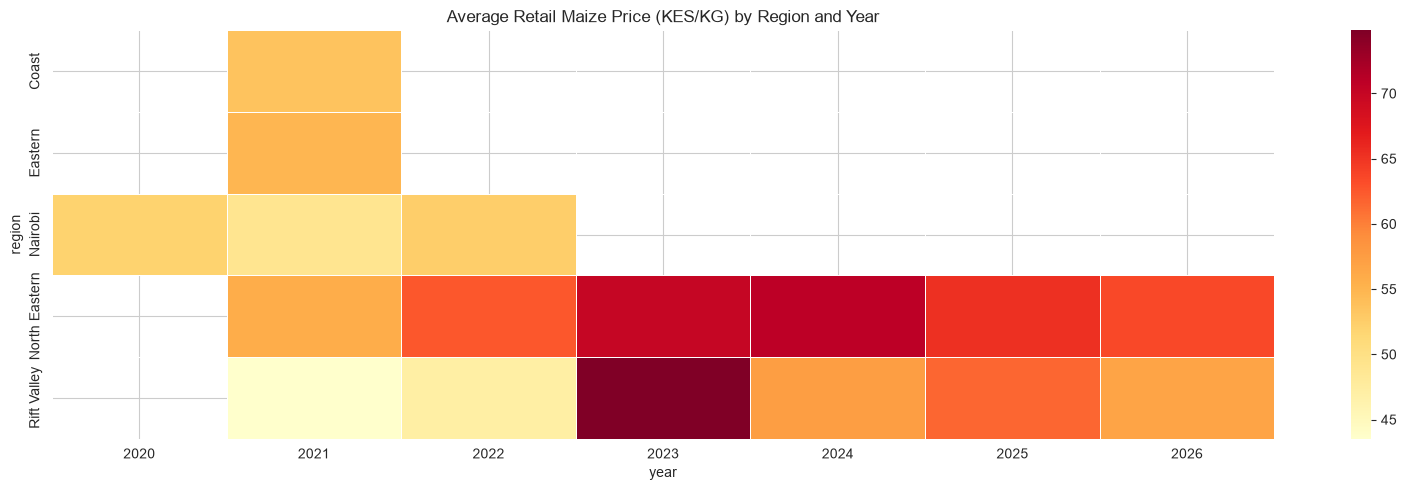

Observation: North Eastern consistently has the highest prices — food insecure arid region.
Clear time effect — all regions show rising prices post-2021.


In [19]:
# Regional price heatmap — Maize by region and year
maize_ry = (
    df_fc[(df_fc['commodity'] == 'Maize') & (df_fc['pricetype'] == 'Retail')]
    .assign(year=lambda x: x['date'].dt.year)
    .groupby(['region', 'year'])['price_per_kg']
    .mean()
    .unstack()
)

plt.figure(figsize=(16, 5))
sns.heatmap(maize_ry, cmap='YlOrRd', annot=False, linewidths=0.5, fmt='.0f')
plt.title('Average Retail Maize Price (KES/KG) by Region and Year')
plt.tight_layout()
plt.savefig('../../data/exports/eda_regional_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Observation: North Eastern consistently has the highest prices — food insecure arid region.')
print('Clear time effect — all regions show rising prices post-2021.')

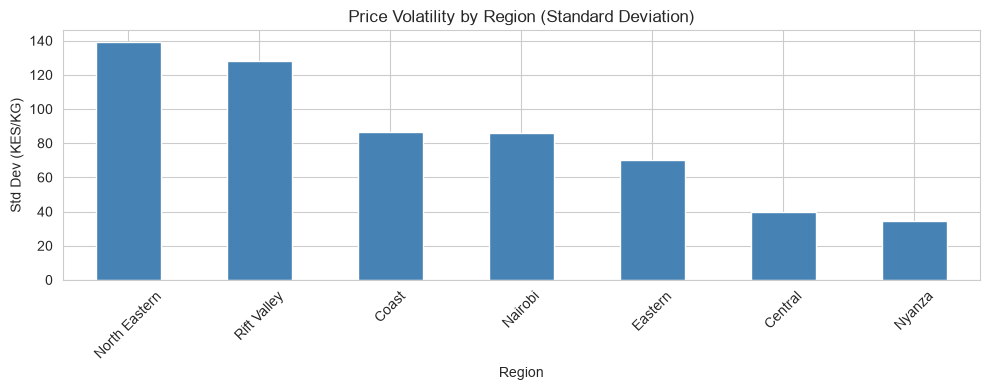

In [20]:
# Price volatility by region
volatility = df_fc.groupby('region')['price_per_kg'].std().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
volatility.plot(kind='bar', color='steelblue')
plt.title('Price Volatility by Region (Standard Deviation)')
plt.xlabel('Region')
plt.ylabel('Std Dev (KES/KG)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 11. Seasonality Analysis

Kenyan agriculture follows distinct rainy/dry seasons:
- **Long Rains (MAM):** March–May — main planting season
- **Short Rains (OND):** October–December — secondary planting
- **Dry Season (JJAS):** June–September
- **Cool Dry (JF):** January–February

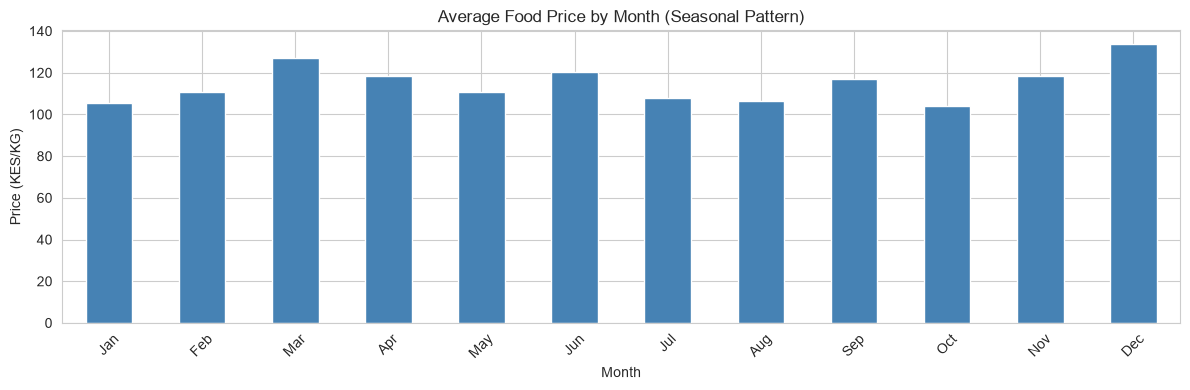

Observation: Prices tend to dip slightly around harvest months (Jul-Aug for long rains crop).


In [21]:
# Seasonal price patterns
df_fc['month'] = df_fc['date'].dt.month
monthly_avg_price = df_fc.groupby('month')['price_per_kg'].mean()

plt.figure(figsize=(12, 4))
monthly_avg_price.plot(kind='bar', color='steelblue')
plt.title('Average Food Price by Month (Seasonal Pattern)')
plt.xlabel('Month')
plt.ylabel('Price (KES/KG)')
plt.xticks(range(12), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
plt.tight_layout()
plt.savefig('../../data/exports/eda_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

print('Observation: Prices tend to dip slightly around harvest months (Jul-Aug for long rains crop).')

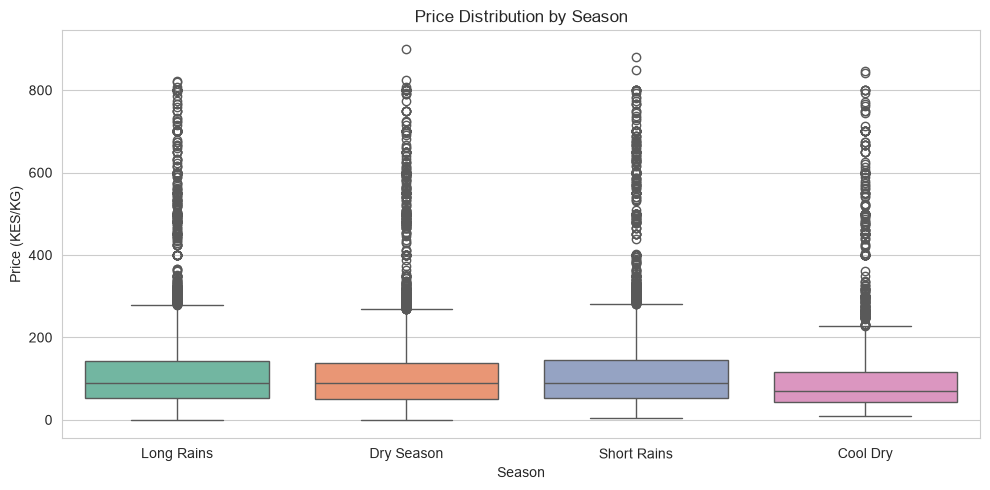

In [22]:
# Season vs price boxplot
plt.figure(figsize=(10, 5))
season_order = ['Long Rains', 'Dry Season', 'Short Rains', 'Cool Dry']
df_plot = df_fc[df_fc['season'].isin(season_order)]
sns.boxplot(data=df_plot, x='season', y='price_per_kg', order=season_order, palette='Set2')
plt.title('Price Distribution by Season')
plt.xlabel('Season')
plt.ylabel('Price (KES/KG)')
plt.tight_layout()
plt.show()

## 12. Rainfall & Price Relationship

Rainfall is expected to influence food prices through crop production — but the effect is **lagged**, not immediate. Heavy rainfall in March (planting) affects prices in July–August (harvest).

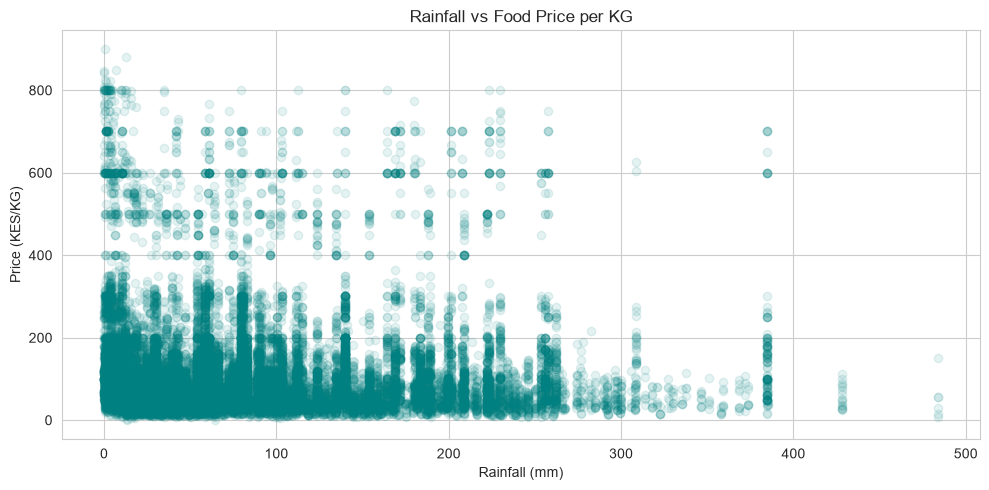

Same-month correlation: -0.028
Observation: Weak same-month correlation — rainfall effect is lagged 3-6 months.


In [23]:
# Rainfall vs price scatter
plt.figure(figsize=(10, 5))
plt.scatter(df_fc['rainfall_mm'], df_fc['price_per_kg'], alpha=0.1, color='teal')
plt.title('Rainfall vs Food Price per KG')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Price (KES/KG)')
plt.tight_layout()
plt.show()

print('Same-month correlation:', df_fc[['rainfall_mm','price_per_kg']].corr().iloc[0,1].round(3))
print('Observation: Weak same-month correlation — rainfall effect is lagged 3-6 months.')

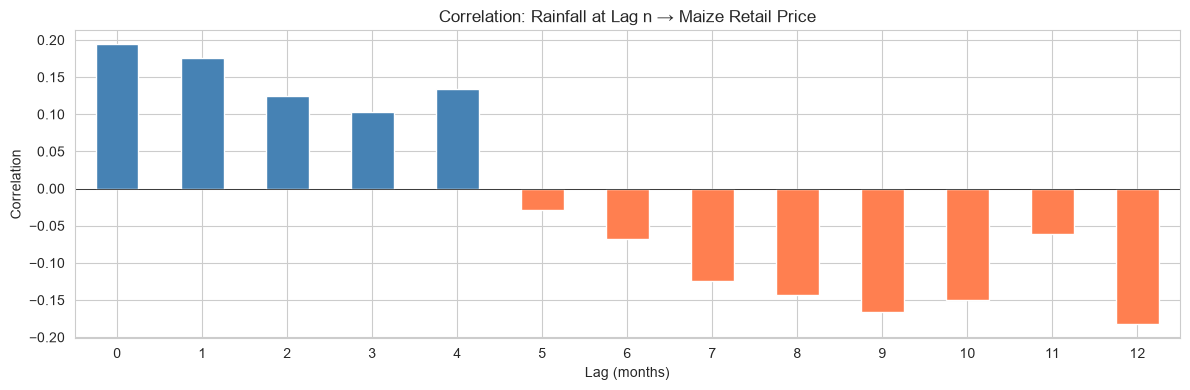

Observation: Rainfall-price correlation grows in magnitude at 3-6 month lag.
This confirms the planting-to-harvest lag in Kenya's agricultural calendar.


In [24]:
# Lagged rainfall correlation — Marren's analysis
maize_retail = df_fc[
    (df_fc['commodity'] == 'Maize') & 
    (df_fc['pricetype'] == 'Retail')
].groupby('date').agg({'price_per_kg': 'mean', 'rainfall_mm': 'mean'}).reset_index()

correlations = {}
for lag in range(0, 13):
    shifted = maize_retail['rainfall_mm'].shift(lag)
    corr = maize_retail['price_per_kg'].corr(shifted)
    correlations[lag] = corr

corr_series = pd.Series(correlations)

plt.figure(figsize=(12, 4))
corr_series.plot(kind='bar', color=['steelblue' if v >= 0 else 'coral' for v in corr_series])
plt.axhline(0, color='black', linewidth=0.5)
plt.title('Correlation: Rainfall at Lag n → Maize Retail Price')
plt.xlabel('Lag (months)')
plt.ylabel('Correlation')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../../data/exports/eda_rainfall_lag_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Observation: Rainfall-price correlation grows in magnitude at 3-6 month lag.')
print('This confirms the planting-to-harvest lag in Kenya\'s agricultural calendar.')

## 13. Wholesale vs Retail Price Comparison

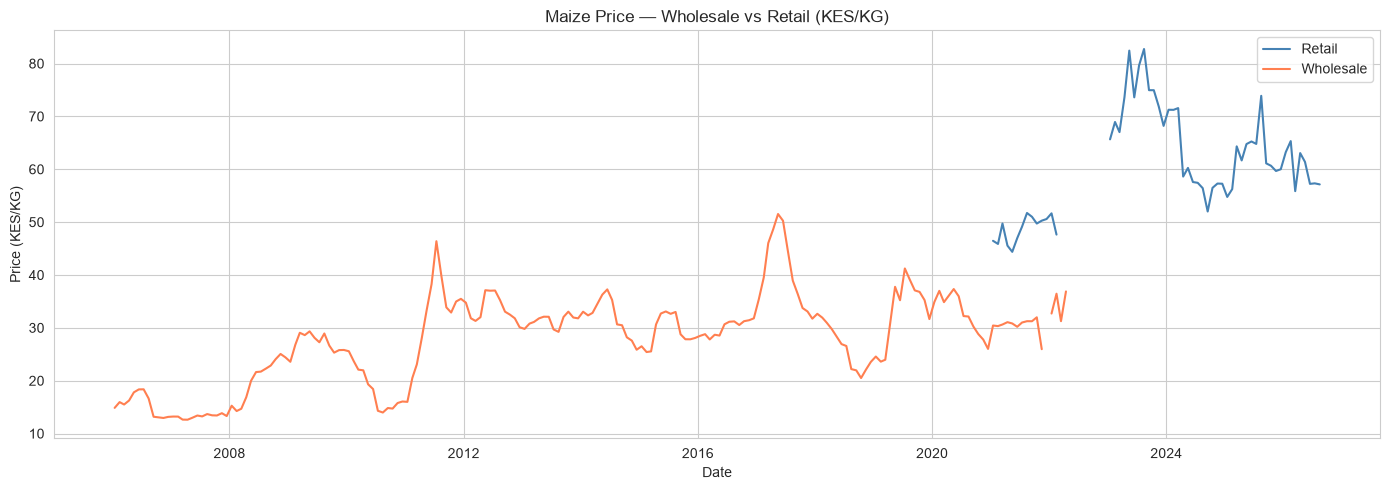

Observation: Wholesale and retail prices move together directionally.
Retail markup over wholesale fluctuates — not constant.


In [25]:
# Wholesale vs Retail maize price comparison
maize_wvr = df_fc[df_fc['commodity'] == 'Maize'].groupby(
    ['date', 'pricetype']
)['price_per_kg'].mean().unstack()

plt.figure(figsize=(14, 5))
if 'Retail' in maize_wvr.columns:
    plt.plot(maize_wvr.index, maize_wvr['Retail'], label='Retail', color='steelblue')
if 'Wholesale' in maize_wvr.columns:
    plt.plot(maize_wvr.index, maize_wvr['Wholesale'], label='Wholesale', color='coral')
plt.title('Maize Price — Wholesale vs Retail (KES/KG)')
plt.xlabel('Date')
plt.ylabel('Price (KES/KG)')
plt.legend()
plt.tight_layout()
plt.savefig('../../data/exports/eda_wholesale_retail.png', dpi=150, bbox_inches='tight')
plt.show()

print('Observation: Wholesale and retail prices move together directionally.')
print('Retail markup over wholesale fluctuates — not constant.')

## 14. Bivariate Analysis — Classification Dataset

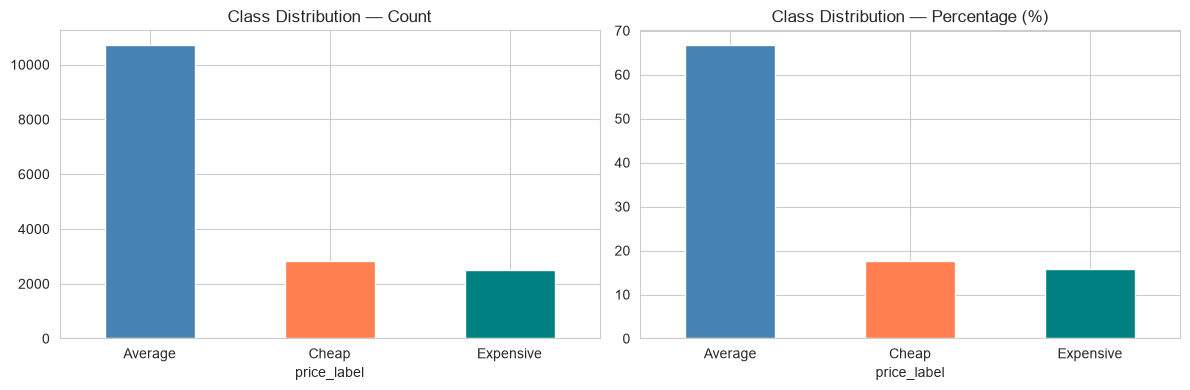

Class balance:
             count  pct (%)
price_label                
Average      10711     66.7
Cheap         2820     17.6
Expensive     2517     15.7

Conclusion: Imbalanced — Average dominates at ~67%. Apply class_weight=balanced.


In [26]:
# Class balance check
counts = df_cl['price_label'].value_counts()
pct = df_cl['price_label'].value_counts(normalize=True).round(3) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral', 'teal'])
axes[0].set_title('Class Distribution — Count')
axes[0].tick_params(axis='x', rotation=0)

pct.plot(kind='bar', ax=axes[1], color=['steelblue', 'coral', 'teal'])
axes[1].set_title('Class Distribution — Percentage (%)')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../../data/exports/eda_class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Class balance:')
print(pd.DataFrame({'count': counts, 'pct (%)': pct}))
print('\nConclusion: Imbalanced — Average dominates at ~67%. Apply class_weight=balanced.')

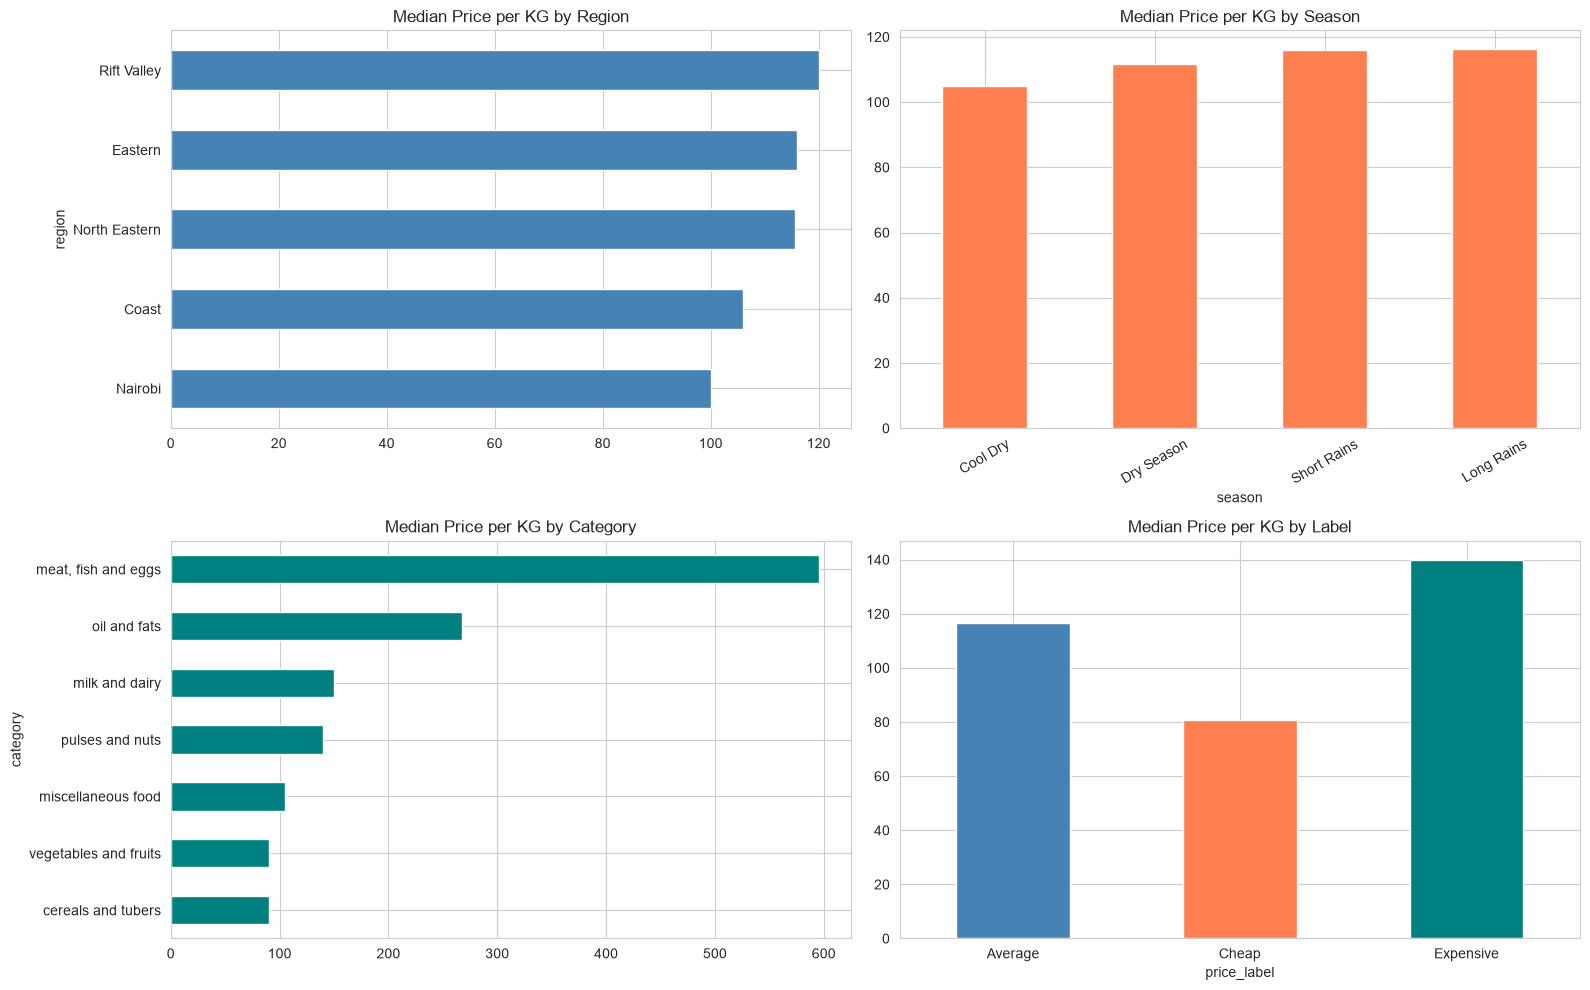

In [27]:
# Bivariate — price_per_kg vs categorical features
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

df_cl.groupby('region')['price_per_kg'].median().sort_values().plot(
    kind='barh', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Median Price per KG by Region')

df_cl.groupby('season')['price_per_kg'].median().sort_values().plot(
    kind='bar', ax=axes[0,1], color='coral')
axes[0,1].set_title('Median Price per KG by Season')
axes[0,1].tick_params(axis='x', rotation=30)

df_cl.groupby('category')['price_per_kg'].median().sort_values().plot(
    kind='barh', ax=axes[1,0], color='teal')
axes[1,0].set_title('Median Price per KG by Category')

df_cl.groupby('price_label')['price_per_kg'].median().plot(
    kind='bar', ax=axes[1,1], color=['steelblue','coral','teal'])
axes[1,1].set_title('Median Price per KG by Label')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../../data/exports/eda_bivariate.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Correlation Analysis

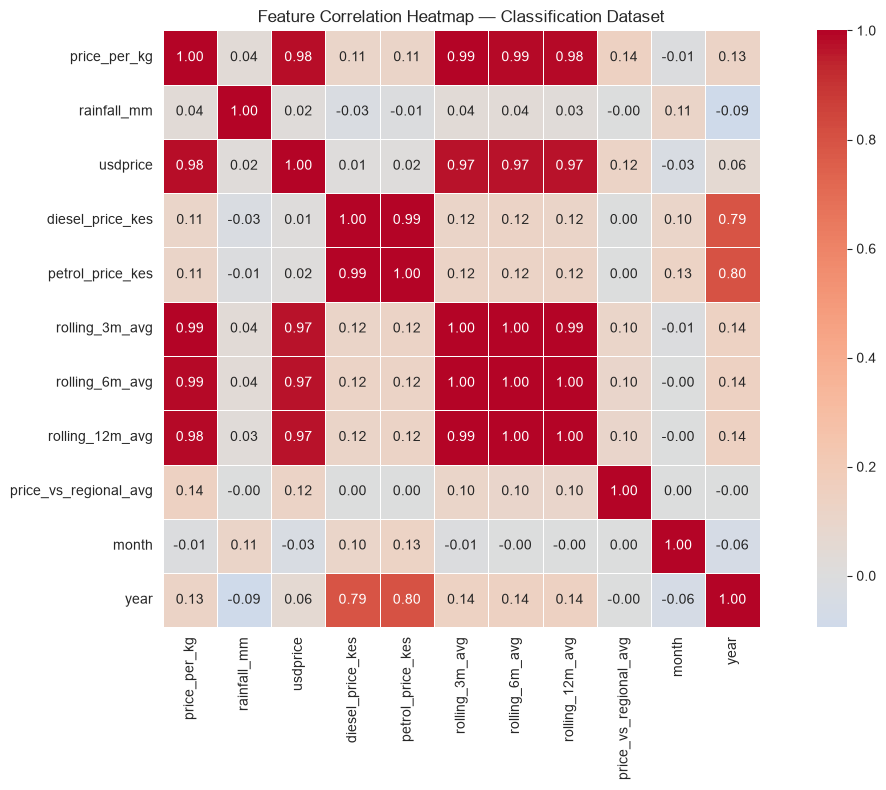

High correlations (>0.85) — features to consider dropping:
  price_per_kg vs usdprice: 0.979
  price_per_kg vs rolling_3m_avg: 0.992
  price_per_kg vs rolling_6m_avg: 0.988
  price_per_kg vs rolling_12m_avg: 0.984
  diesel_price_kes vs petrol_price_kes: 0.992
  rolling_3m_avg vs usdprice: 0.973
  rolling_3m_avg vs rolling_6m_avg: 0.998
  rolling_6m_avg vs usdprice: 0.971
  rolling_12m_avg vs usdprice: 0.969
  rolling_12m_avg vs rolling_3m_avg: 0.994
  rolling_12m_avg vs rolling_6m_avg: 0.998


In [28]:
# Correlation heatmap — classification dataset
corr_cols = ['price_per_kg', 'rainfall_mm', 'usdprice', 
             'diesel_price_kes', 'petrol_price_kes',
             'rolling_3m_avg', 'rolling_6m_avg', 'rolling_12m_avg',
             'price_vs_regional_avg', 'month', 'year']

corr = df_cl[corr_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Heatmap — Classification Dataset')
plt.tight_layout()
plt.savefig('../../data/exports/eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('High correlations (>0.85) — features to consider dropping:')
for col1 in corr_cols:
    for col2 in corr_cols:
        if col1 < col2:
            val = corr.loc[col1, col2]
            if abs(val) > 0.85:
                print(f'  {col1} vs {col2}: {val:.3f}')

## 16. SARIMA Feasibility Check

Before modeling, we verify that the Maize price series satisfies SARIMA requirements: sufficient length, no gaps, clear seasonality, and stationarity after differencing.

In [29]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# Best series: Nairobi Wholesale Maize
maize_nairobi = df_fc[
    (df_fc['commodity'] == 'Maize') & 
    (df_fc['market'] == 'Nairobi') &
    (df_fc['pricetype'] == 'Wholesale')
].sort_values('date').copy()

print('Maize Nairobi Wholesale:')
print('Records:', len(maize_nairobi))
print('Date range:', maize_nairobi['date'].min().date(), 'to', maize_nairobi['date'].max().date())
print('Gaps:', len(maize_nairobi) - maize_nairobi['date'].dt.to_period('M').nunique())

Maize Nairobi Wholesale:
Records: 189
Date range: 2006-01-15 to 2022-03-15
Gaps: 0


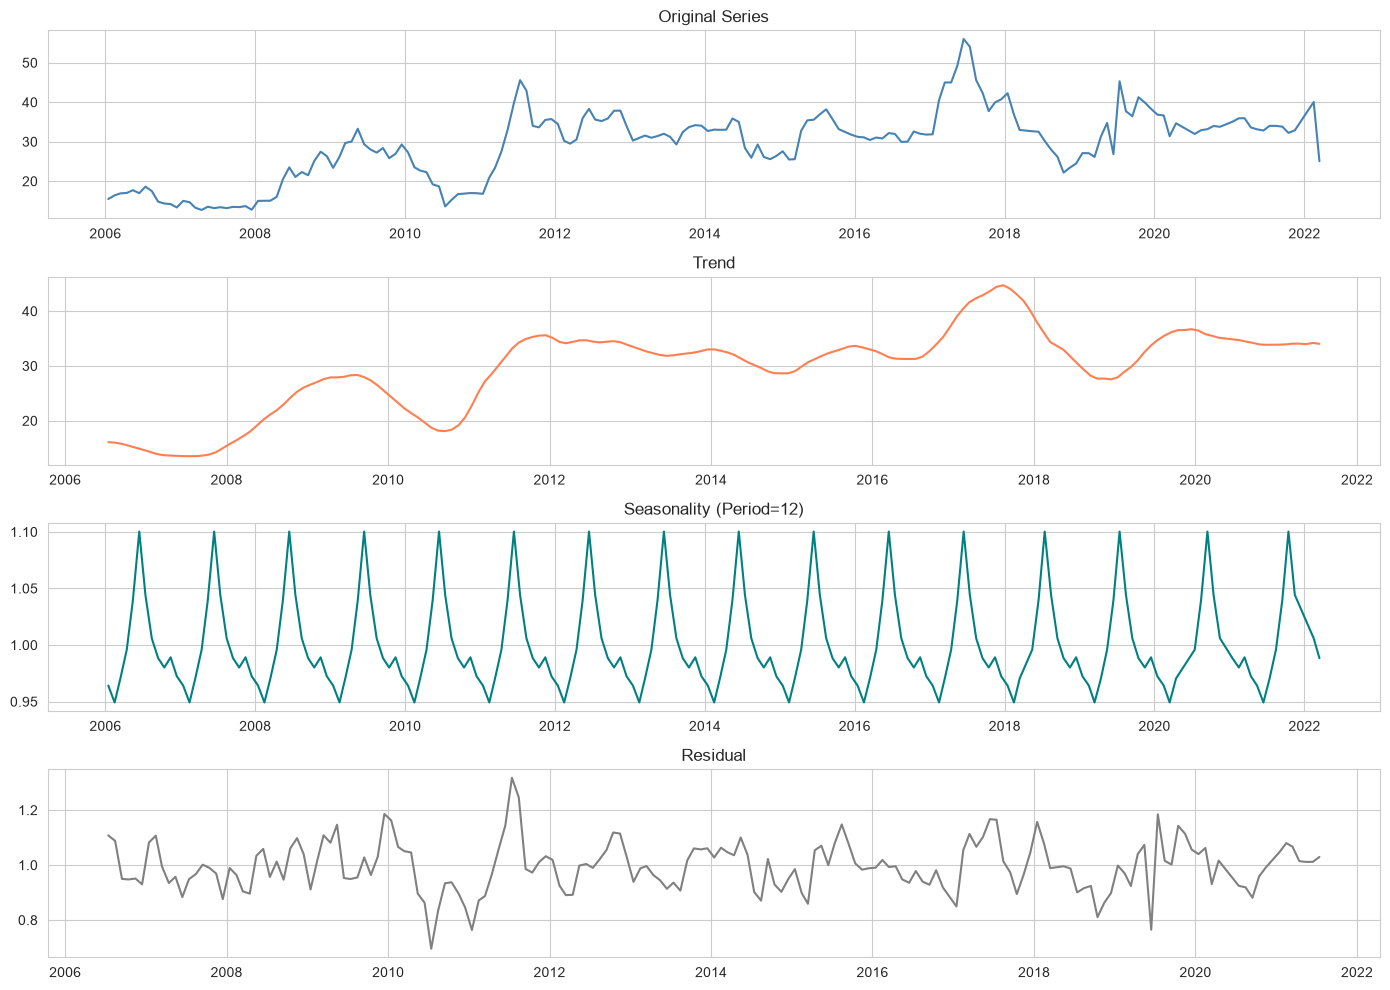

In [30]:
# Decomposition
series = maize_nairobi.set_index('date')['price_per_kg']
result = seasonal_decompose(series, model='multiplicative', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
axes[0].plot(series, color='steelblue')
axes[0].set_title('Original Series')
axes[1].plot(result.trend, color='coral')
axes[1].set_title('Trend')
axes[2].plot(result.seasonal, color='teal')
axes[2].set_title('Seasonality (Period=12)')
axes[3].plot(result.resid, color='grey')
axes[3].set_title('Residual')
plt.tight_layout()
plt.savefig('../../data/exports/eda_sarima_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# Stationarity test
adf_result = adfuller(series.dropna())
print('=== Augmented Dickey-Fuller Test ===')
print('ADF Statistic:', round(adf_result[0], 4))
print('p-value:', round(adf_result[1], 4))

if adf_result[1] < 0.05:
    print('Result: STATIONARY — SARIMA can be applied directly')
else:
    print('Result: NON-STATIONARY — need to difference (d=1)')

# Test after differencing
series_diff = series.diff().dropna()
adf_diff = adfuller(series_diff)
print('\nAfter differencing:')
print('p-value:', round(adf_diff[1], 4))
print('Result: STATIONARY ✓' if adf_diff[1] < 0.05 else 'Still non-stationary')

print('\nConclusion: Use SARIMA(p,1,q)(P,1,Q,12) — d=1 confirmed.')

=== Augmented Dickey-Fuller Test ===
ADF Statistic: -2.7788
p-value: 0.0614
Result: NON-STATIONARY — need to difference (d=1)

After differencing:
p-value: 0.0
Result: STATIONARY ✓

Conclusion: Use SARIMA(p,1,q)(P,1,Q,12) — d=1 confirmed.


## 17. Key Findings & Modeling Decisions

In [32]:
print('=== EDA KEY FINDINGS ===')
print()
print('DATA QUALITY:')
print('  - 27,316 records after cleaning (dropped 68 null-location rows)')
print('  - No duplicate records')
print('  - 2026 rainfall nulls filled via NASA POWER API (2025 same-month proxy)')
print('  - Unit inconsistency resolved via price_per_kg normalization')
print('  - 27 of 47 Kenya counties covered — noted as limitation')
print()
print('EDA FINDINGS:')
print('  1. Rift Valley dominates records (44%) — Kenya\'s agricultural heartland')
print('  2. Maize prices tripled: ~KES 15/kg (2006) → ~KES 62/kg (2026)')
print('  3. 2022-2023 spike to KES 83/kg — Russia-Ukraine war effect')
print('  4. Weak same-month rainfall-price correlation (r≈0.05)')
print('  5. Rainfall-price correlation grows at 3-6 month lag — confirms planting cycle')
print('  6. North Eastern has highest price volatility — food insecure arid region')
print('  7. Strong seasonality confirmed — SARIMA with period=12 justified')
print('  8. Series non-stationary (p=0.06) → stationary after d=1 (p=0.0)')
print()
print('MODELING DECISIONS:')
print('  1. Log-transform price_per_kg before classification (skewness=2.55)')
print('  2. Apply class_weight=balanced (67% Average, 17% Cheap, 16% Expensive)')
print('  3. Drop usdprice, petrol_price_kes, rolling_3m_avg, rolling_6m_avg (corr>0.85)')
print('  4. Keep: region, commodity, market, season, month, year, rainfall_mm,')
print('           diesel_price_kes, rolling_12m_avg, price_vs_regional_avg, lat, lon')
print('  5. SARIMA: d=1, D=1, S=12 — determine p,q,P,Q from ACF/PACF')
print('  6. SVAR: Use rainfall lags (3,6 months) + diesel + usdprice as system variables')

=== EDA KEY FINDINGS ===

DATA QUALITY:
  - 27,316 records after cleaning (dropped 68 null-location rows)
  - No duplicate records
  - 2026 rainfall nulls filled via NASA POWER API (2025 same-month proxy)
  - Unit inconsistency resolved via price_per_kg normalization
  - 27 of 47 Kenya counties covered — noted as limitation

EDA FINDINGS:
  1. Rift Valley dominates records (44%) — Kenya's agricultural heartland
  2. Maize prices tripled: ~KES 15/kg (2006) → ~KES 62/kg (2026)
  3. 2022-2023 spike to KES 83/kg — Russia-Ukraine war effect
  4. Weak same-month rainfall-price correlation (r≈0.05)
  5. Rainfall-price correlation grows at 3-6 month lag — confirms planting cycle
  6. North Eastern has highest price volatility — food insecure arid region
  7. Strong seasonality confirmed — SARIMA with period=12 justified
  8. Series non-stationary (p=0.06) → stationary after d=1 (p=0.0)

MODELING DECISIONS:
  1. Log-transform price_per_kg before classification (skewness=2.55)
  2. Apply class_w

# Time Series EDA
- Crop yield / long-term trends forecasting
- Rainfall analysis
- Price forecasting

This notebook works through: converting to a time series, visual inspection, rolling statistics, ADF stationarity testing, transformation (log + differencing), and re-testing.

**Series used:**
- **Maize (white) retail price** — monthly national average (2006–2020)
- **Rainfall** — monthly national average (2006–2026)


## Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

sns.set_style("whitegrid")
%matplotlib inline

## Load datasets

The rainfall data has already been merged into the price data, so we only need **`wfp_with_rainfall.csv`**.

In [2]:
df = pd.read_csv("wfp_with_rainfall.csv", parse_dates=["date"])
df.head()

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice,date_month,rainfall_mm
0,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,cereals and tubers,Maize,51,KG,actual,Wholesale,KES,16.13,0.22,2006-01-01,17.813333
1,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,cereals and tubers,Maize (white),67,90 KG,actual,Wholesale,KES,1480.00,20.58,2006-01-01,17.813333
2,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,pulses and nuts,Beans,50,KG,actual,Wholesale,KES,33.63,0.47,2006-01-01,17.813333
3,2006-01-15,Coast,Mombasa,Mombasa,191,-4.05,39.67,pulses and nuts,Beans (dry),262,90 KG,actual,Wholesale,KES,3246.00,45.15,2006-01-01,17.813333
4,2006-01-15,Eastern,Kitui,Kitui,187,-1.37,38.02,cereals and tubers,Maize (white),67,KG,actual,Retail,KES,17.00,0.24,2006-01-01,44.527500


In [3]:
df.shape, df["date"].min(), df["date"].max()

((27316, 18),
 Timestamp('2006-01-15 00:00:00'),
 Timestamp('2026-08-15 00:00:00'))

## 1. Convert the data to a time series format

The raw data is at the market x commodity x month level. We aggregate to a single **national monthly average** for:
- Maize (white), Retail price
- Rainfall (mm)

In [4]:
maize = df[(df["commodity"] == "Maize (white)") & (df["pricetype"] == "Retail")]

price_ts = maize.groupby("date")["price"].mean().sort_index()
price_ts.index = pd.DatetimeIndex(price_ts.index).to_period("M").to_timestamp()

rain_ts = df.groupby("date")["rainfall_mm"].mean().sort_index()
rain_ts.index = pd.DatetimeIndex(rain_ts.index).to_period("M").to_timestamp()

print("Maize price series:", price_ts.shape, price_ts.index.min(), "->", price_ts.index.max())
print("Rainfall series:   ", rain_ts.shape, rain_ts.index.min(), "->", rain_ts.index.max())

Maize price series: (180,) 2006-01-01 00:00:00 -> 2020-12-01 00:00:00
Rainfall series:    (248,) 2006-01-01 00:00:00 -> 2026-08-01 00:00:00


Note: rainfall data extends further (to 2026) than maize price data (to 2020). Keep this in mind if you later combine the two series — you'll want to restrict to the overlapping window.

## 2. Plot the time series data to visually inspect trends

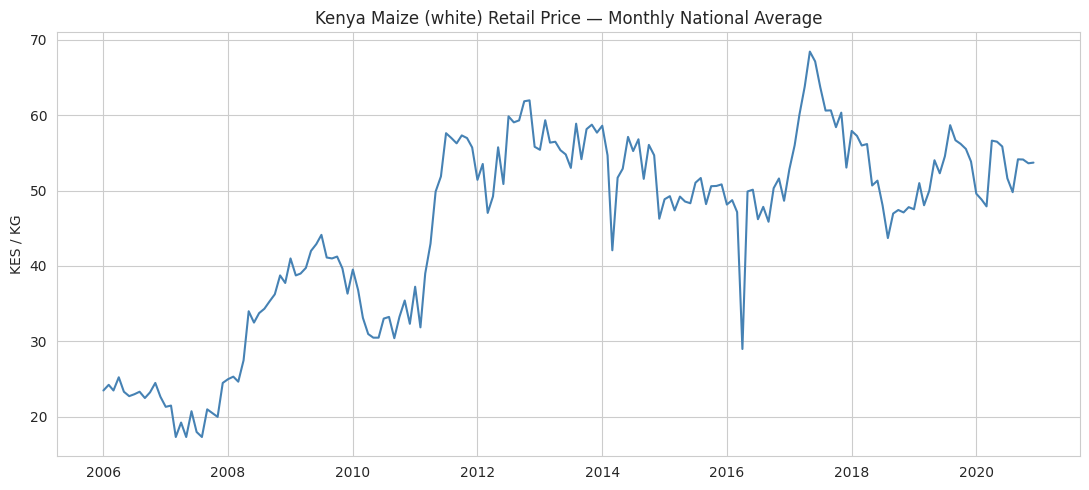

In [5]:
plt.figure(figsize=(11, 5))
plt.plot(price_ts, color="steelblue")
plt.title("Kenya Maize (white) Retail Price — Monthly National Average")
plt.ylabel("KES / KG")
plt.tight_layout()
plt.show()

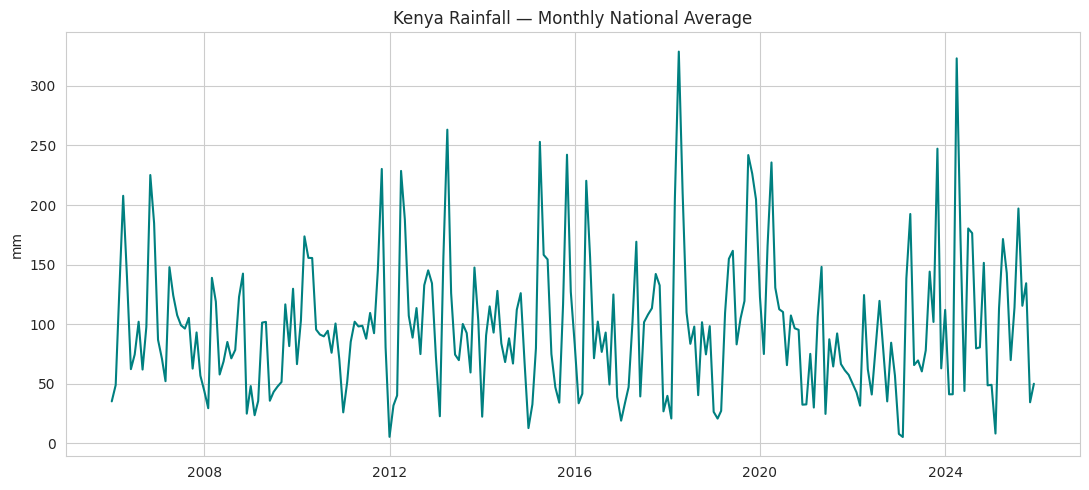

In [6]:
plt.figure(figsize=(11, 5))
plt.plot(rain_ts, color="teal")
plt.title("Kenya Rainfall — Monthly National Average")
plt.ylabel("mm")
plt.tight_layout()
plt.show()

**Observations:**
- Maize price shows a strong long-run upward trend (roughly tripling from 2006 to 2020), a sharp crash/spike around 2016, and generally rising volatility — a classic non-stationary series.
- Rainfall oscillates around a fairly stable mean with a clear yearly seasonal cycle — no obvious trend, so it is likely closer to stationary already.

## 3. Calculate and plot rolling statistics

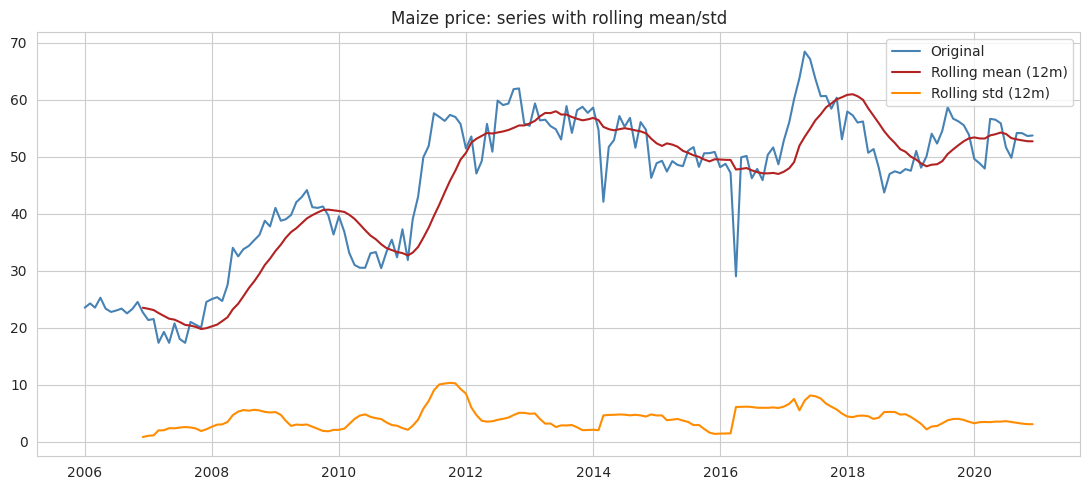

In [7]:
def rolling_plot(series, label, window=12):
    roll_mean = series.rolling(window).mean()
    roll_std = series.rolling(window).std()
    plt.figure(figsize=(11, 5))
    plt.plot(series, label="Original", color="steelblue")
    plt.plot(roll_mean, label=f"Rolling mean ({window}m)", color="firebrick")
    plt.plot(roll_std, label=f"Rolling std ({window}m)", color="darkorange")
    plt.title(f"{label}: series with rolling mean/std")
    plt.legend()
    plt.tight_layout()
    plt.show()

rolling_plot(price_ts, "Maize price")

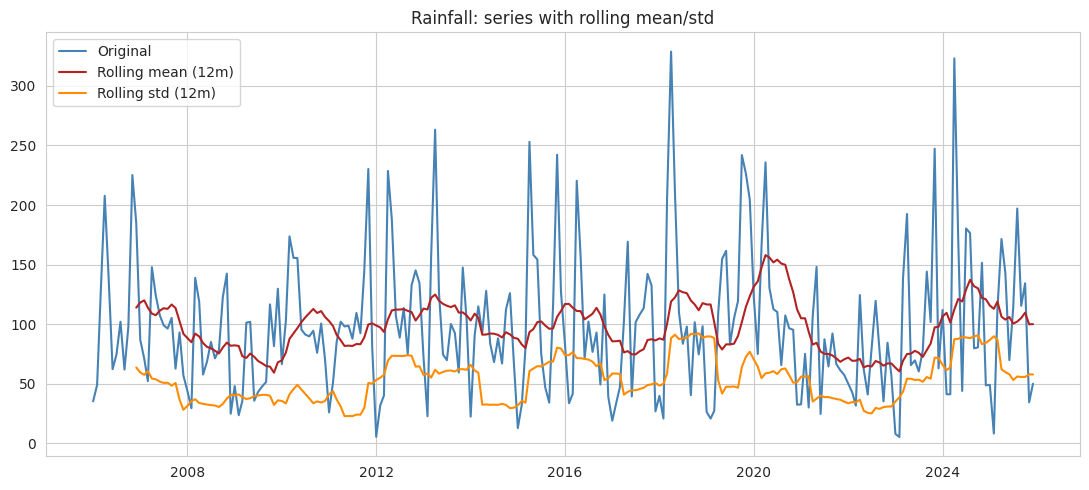

In [8]:
rolling_plot(rain_ts, "Rainfall")

For maize price, the rolling mean is clearly not flat — it drifts upward over time, another sign of non-stationarity. Rainfall's rolling mean is comparatively flat, while its rolling std shows a repeating seasonal wobble.

## 4. Perform ADF test on the original series
Records: ADF test statistic, p-value, number of lags, critical values.

In [9]:
def adf_report(series, label):
    result = adfuller(series.dropna(), autolag="AIC")
    print(f"--- ADF test: {label} ---")
    print(f"ADF statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.5f}")
    print(f"# lags used   : {result[2]}")
    print(f"# observations: {result[3]}")
    print("Critical values:")
    for k, v in result[4].items():
        print(f"   {k}: {v:.4f}")
    print()
    return result

adf_price_raw = adf_report(price_ts, "Maize price (original)")

--- ADF test: Maize price (original) ---
ADF statistic : -1.9155
p-value       : 0.32480
# lags used   : 1
# observations: 178
Critical values:
   1%: -3.4676
   5%: -2.8779
   10%: -2.5755



In [10]:
adf_rain_raw = adf_report(rain_ts, "Rainfall (original)")

--- ADF test: Rainfall (original) ---
ADF statistic : -4.3837
p-value       : 0.00032
# lags used   : 13
# observations: 226
Critical values:
   1%: -3.4596
   5%: -2.8744
   10%: -2.5736



**Reading the results:**
- Maize price: p-value ≈ 0.32 (well above 0.05) → **fail to reject** the null of a unit root → **non-stationary**.
- Rainfall: p-value ≈ 0.0003 (well below 0.05) → **reject** the null → already **stationary**. This matches the visual inspection above.

## 5. Decide whether transformation is necessary

- **Maize price** is non-stationary with a strong trend and increasing variance → apply a **log transform** (stabilizes variance) followed by **first-order differencing** (removes the trend).
- **Rainfall** is already stationary in levels, so differencing isn't required to achieve stationarity — but rainfall is strongly *seasonal*, so a **seasonal difference (lag 12)** is useful if you want to strip out the yearly cycle and study anomalies (e.g. drought/flood years) rather than the raw seasonal swing.

In [11]:
# Maize: log transform + first-order differencing
log_price = np.log(price_ts)
log_price_diff = log_price.diff().dropna()

# Rainfall: seasonal differencing (lag 12)
rain_diff = rain_ts.diff(12).dropna()

## 6. Plot the transformed/differenced series

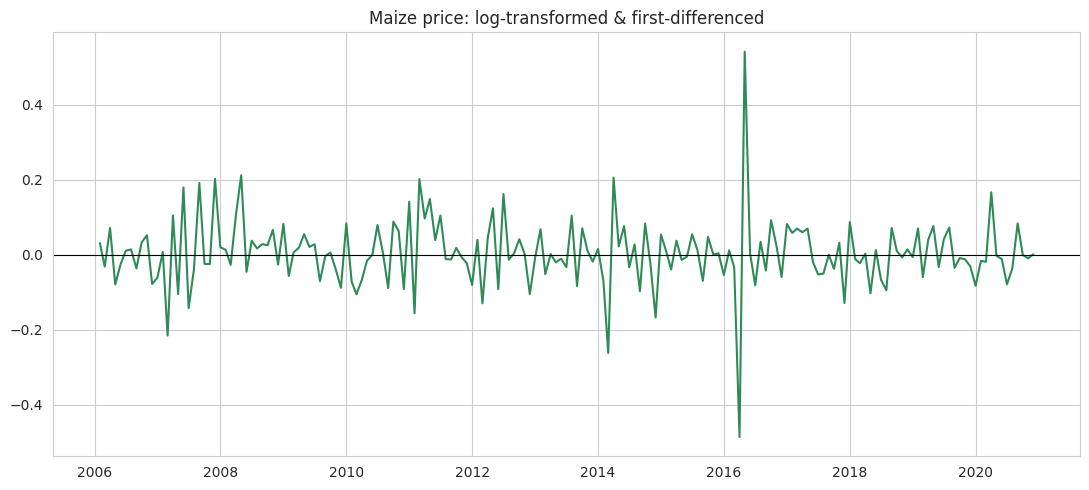

In [12]:
plt.figure(figsize=(11, 5))
plt.plot(log_price_diff, color="seagreen")
plt.title("Maize price: log-transformed & first-differenced")
plt.axhline(0, color="black", lw=0.8)
plt.tight_layout()
plt.show()

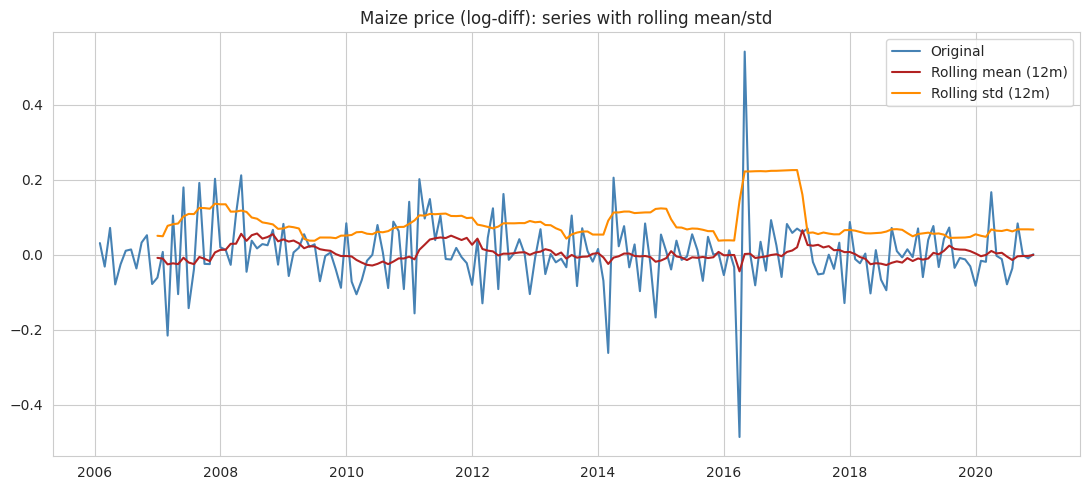

In [13]:
rolling_plot(log_price_diff, "Maize price (log-diff)")

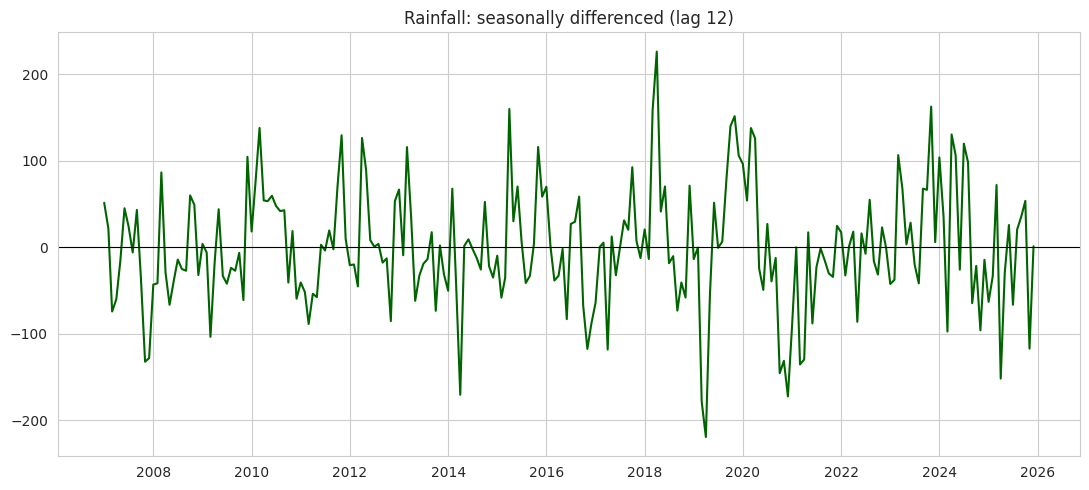

In [14]:
plt.figure(figsize=(11, 5))
plt.plot(rain_diff, color="darkgreen")
plt.title("Rainfall: seasonally differenced (lag 12)")
plt.axhline(0, color="black", lw=0.8)
plt.tight_layout()
plt.show()

The differenced maize price series now fluctuates around zero with a roughly constant rolling mean and std — much closer to stationary. The seasonally-differenced rainfall series shows deviations from the typical yearly pattern (positive = wetter than usual for that month, negative = drier).

## 7. Perform ADF again

In [15]:
adf_price_diff = adf_report(log_price_diff, "Maize price (log, 1st-differenced)")

--- ADF test: Maize price (log, 1st-differenced) ---
ADF statistic : -18.5194
p-value       : 0.00000
# lags used   : 0
# observations: 178
Critical values:
   1%: -3.4676
   5%: -2.8779
   10%: -2.5755



In [16]:
adf_rain_diff = adf_report(rain_diff, "Rainfall (seasonally differenced, lag 12)")

--- ADF test: Rainfall (seasonally differenced, lag 12) ---
ADF statistic : -4.9967
p-value       : 0.00002
# lags used   : 13
# observations: 214
Critical values:
   1%: -3.4613
   5%: -2.8751
   10%: -2.5740



**Result:** both transformed series now have p-values effectively at 0 → **reject the null of a unit root** → both are **stationary**. The log-differenced maize price series and the seasonally-differenced rainfall series are ready for stationarity-dependent modeling (e.g. ARIMA on the maize price, or using the rainfall anomaly as an exogenous regressor).

## Summary

In [17]:
summary = pd.DataFrame([
    {"series": "Maize price (original)", "ADF stat": adf_price_raw[0], "p-value": adf_price_raw[1],
     "lags": adf_price_raw[2], "n obs": adf_price_raw[3], "stationary (5%)": adf_price_raw[1] < 0.05},
    {"series": "Maize price (log, differenced)", "ADF stat": adf_price_diff[0], "p-value": adf_price_diff[1],
     "lags": adf_price_diff[2], "n obs": adf_price_diff[3], "stationary (5%)": adf_price_diff[1] < 0.05},
    {"series": "Rainfall (original)", "ADF stat": adf_rain_raw[0], "p-value": adf_rain_raw[1],
     "lags": adf_rain_raw[2], "n obs": adf_rain_raw[3], "stationary (5%)": adf_rain_raw[1] < 0.05},
    {"series": "Rainfall (seasonally differenced)", "ADF stat": adf_rain_diff[0], "p-value": adf_rain_diff[1],
     "lags": adf_rain_diff[2], "n obs": adf_rain_diff[3], "stationary (5%)": adf_rain_diff[1] < 0.05},
])
summary

,series,ADF stat,p-value,lags,n obs,stationary (5%)
0,Maize price (original),-1.915511,3.248000e-01,1,178,False
1,"Maize price (log, differenced)",-18.519416,2.109639e-30,0,178,True
2,Rainfall (original),-4.383717,3.171599e-04,13,226,True
3,Rainfall (seasonally differenced),-4.996708,2.252855e-05,13,214,True


---
# Rainfall Analysis: Seasonal Decomposition

Rainfall is strongly seasonal but not trending, so rather than modeling it directly, it's more useful to split it into **trend**, **seasonal**, and **residual** components. The residual is where drought/flood anomalies show up — months that were much wetter or drier than the seasonal pattern would predict.

Missing rainfall months before cleanup:
date
2026-01-01   NaN
2026-02-01   NaN
2026-03-01   NaN
2026-04-01   NaN
2026-05-01   NaN
2026-06-01   NaN
2026-07-01   NaN
2026-08-01   NaN
Freq: MS, Name: rainfall_mm, dtype: float64


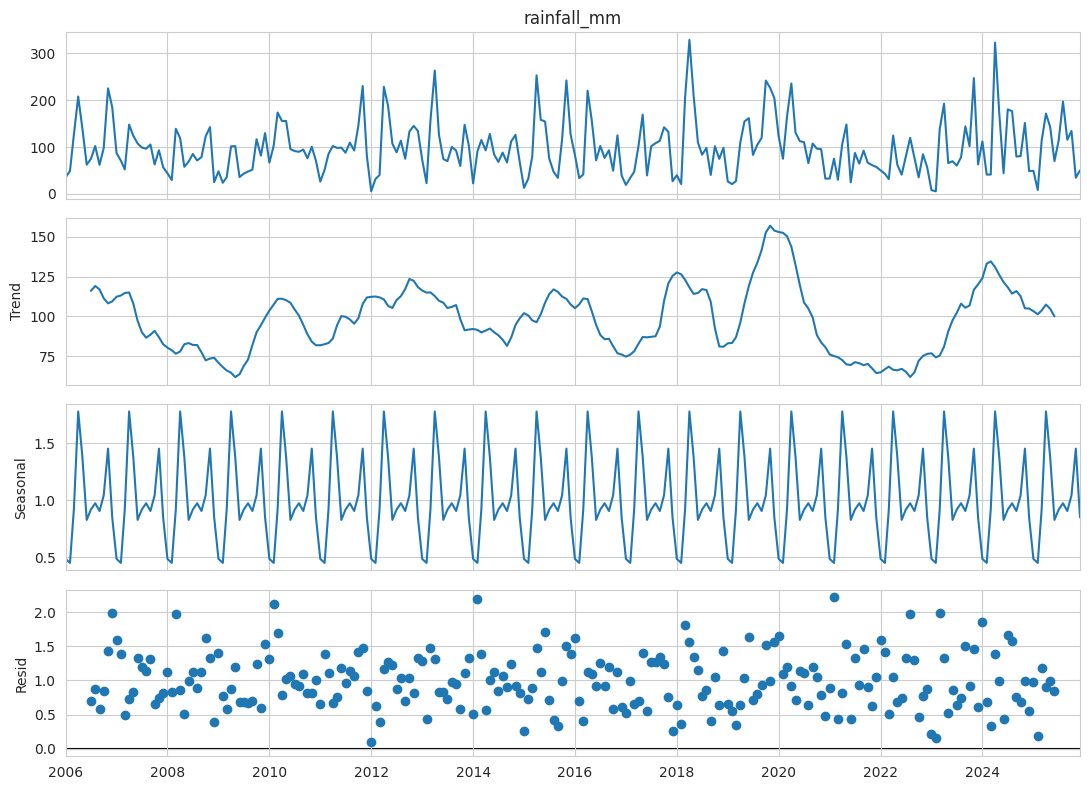

In [18]:
from statsmodels.tsa.seasonal import seasonal_decompose

# A few of the most recent months have missing rainfall values (not yet recorded) —
# seasonal_decompose can't handle NaNs, so drop any leading/trailing missing months.
print("Missing rainfall months before cleanup:")
print(rain_ts[rain_ts.isna()])

rain_ts_clean = rain_ts.dropna()

# Multiplicative decomposition suits rainfall well since variance scales with the
# seasonal level (e.g. a "wet season" month varies more in absolute mm than a dry one).
# Rainfall can be 0 in some months, so guard against divide-by-zero by using additive
# if any zeros are present.
if (rain_ts_clean == 0).any():
    model_type = "additive"
else:
    model_type = "multiplicative"

decomp = seasonal_decompose(rain_ts_clean, model=model_type, period=12)

fig = decomp.plot()
fig.set_size_inches(11, 8)
plt.tight_layout()
plt.show()

**Reading the decomposition:**
- **Trend**: the smoothed long-run level of rainfall — should be roughly flat if there's no long-term drying/wetting trend.
- **Seasonal**: the repeating within-year pattern (Kenya's long-rains/short-rains cycle).
- **Residual**: what's left after removing trend and seasonality — sustained negative stretches indicate drought periods, sustained positive stretches indicate unusually wet periods (flood risk).

In [19]:
# Flag the driest and wettest residual months as candidate drought/flood signals
resid = decomp.resid.dropna()
print("Top 5 driest anomalies (relative to seasonal norm):")
print(resid.sort_values().head(5))
print()
print("Top 5 wettest anomalies (relative to seasonal norm):")
print(resid.sort_values(ascending=False).head(5))

Top 5 driest anomalies (relative to seasonal norm):
date
2012-01-01    0.101460
2023-02-01    0.161125
2025-02-01    0.181691
2023-01-01    0.213522
2017-12-01    0.252339
Name: resid, dtype: float64

Top 5 wettest anomalies (relative to seasonal norm):
date
2021-02-01    2.216948
2014-02-01    2.197106
2010-02-01    2.124996
2023-03-01    1.990867
2006-12-01    1.983852
Name: resid, dtype: float64


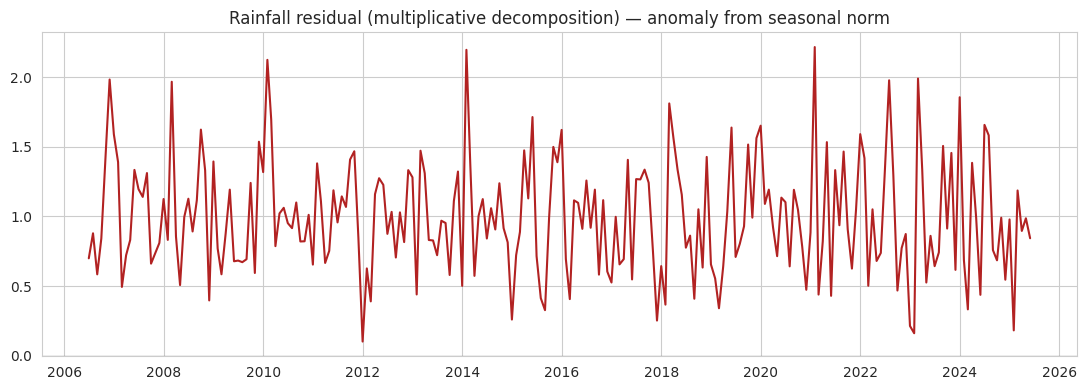

In [20]:
plt.figure(figsize=(11, 4))
plt.plot(resid, color="firebrick")
plt.axhline(0, color="black", lw=0.8)
plt.title(f"Rainfall residual ({model_type} decomposition) — anomaly from seasonal norm")
plt.tight_layout()
plt.show()

Note: `rain_ts` (used later for the price forecast) still has the full range including any trailing missing months — the SARIMAX section below re-aligns it against the price series anyway, so this doesn't cause issues downstream.

---
# Price Forecasting: SARIMA / SARIMAX

We model the **log maize price** with a seasonal ARIMA. Two versions are fit:
1. **SARIMA** — price only, no external inputs.
2. **SARIMAX** — same model, with **rainfall as an exogenous regressor**, since rainfall affects maize supply and therefore price (often with a lag, since a drought affects the harvest, not the same month's price).

Since rainfall data only overlaps with price data through Dec 2020, both series are restricted to that shared window.

In [21]:
# Align to the overlapping window (price data ends earlier than rainfall data)
common_start = max(log_price.index.min(), rain_ts.index.min())
common_end = min(log_price.index.max(), rain_ts.index.max())

log_price_aligned = log_price.loc[common_start:common_end]
rain_aligned = rain_ts.loc[common_start:common_end]

print(f"Aligned range: {common_start.date()} to {common_end.date()}  ({len(log_price_aligned)} months)")

Aligned range: 2006-01-01 to 2020-12-01  (180 months)


In [22]:
# Train/test split — hold out the last 12 months for evaluation
n_test = 12
train_price = log_price_aligned.iloc[:-n_test]
test_price = log_price_aligned.iloc[-n_test:]
train_rain = rain_aligned.iloc[:-n_test]
test_rain = rain_aligned.iloc[-n_test:]

print("Train:", train_price.index.min(), "->", train_price.index.max(), f"({len(train_price)} obs)")
print("Test: ", test_price.index.min(), "->", test_price.index.max(), f"({len(test_price)} obs)")

Train: 2006-01-01 00:00:00 -> 2019-12-01 00:00:00 (168 obs)
Test:  2020-01-01 00:00:00 -> 2020-12-01 00:00:00 (12 obs)


**Model order:** based on the earlier ADF results, the price series needs **d=1** (first differencing) to become stationary, and rainfall showed a 12-month seasonal cycle, so we include a seasonal term with `s=12`. Starting point: `SARIMA(1,1,1)(1,1,0,12)` — a reasonable general-purpose order for a trending, seasonally-influenced series. In practice you'd tune this further with `pmdarima.auto_arima` or by inspecting ACF/PACF plots.

In [23]:
order = (1, 1, 1)
seasonal_order = (1, 1, 0, 12)

# --- Model A: SARIMA, price only ---
model_sarima = sm.tsa.statespace.SARIMAX(
    train_price,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
fit_sarima = model_sarima.fit(disp=False)
print(fit_sarima.summary())

                                      SARIMAX Results                                      
Dep. Variable:                               price   No. Observations:                  168
Model:             SARIMAX(1, 1, 1)x(1, 1, [], 12)   Log Likelihood                 112.723
Date:                             Thu, 27 Aug 2026   AIC                           -217.446
Time:                                     11:13:41   BIC                           -205.622
Sample:                                 01-01-2006   HQIC                          -212.641
                                      - 12-01-2019                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3752      0.188     -1.992      0.046      -0.744      -0.006
ma.L1         -0.0270      

In [24]:
# --- Model B: SARIMAX, price with rainfall as exogenous regressor ---
model_sarimax = sm.tsa.statespace.SARIMAX(
    train_price,
    exog=train_rain,
    order=order,
    seasonal_order=seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
fit_sarimax = model_sarimax.fit(disp=False)
print(fit_sarimax.summary())

                                      SARIMAX Results                                      
Dep. Variable:                               price   No. Observations:                  168
Model:             SARIMAX(1, 1, 1)x(1, 1, [], 12)   Log Likelihood                 113.878
Date:                             Thu, 27 Aug 2026   AIC                           -217.756
Time:                                     11:13:41   BIC                           -202.976
Sample:                                 01-01-2006   HQIC                          -211.750
                                      - 12-01-2019                                         
Covariance Type:                               opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
rainfall_mm    -0.0002      0.000     -1.633      0.103      -0.001    4.88e-05
ar.L1          -0.3990  

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [25]:
print(f"AIC — SARIMA (price only):        {fit_sarima.aic:.2f}")
print(f"AIC — SARIMAX (price + rainfall):   {fit_sarimax.aic:.2f}")
print("(Lower AIC = better fit, penalized for complexity)")

AIC — SARIMA (price only):        -217.45
AIC — SARIMAX (price + rainfall):   -217.76
(Lower AIC = better fit, penalized for complexity)


## Forecast the held-out 12 months and compare to actuals

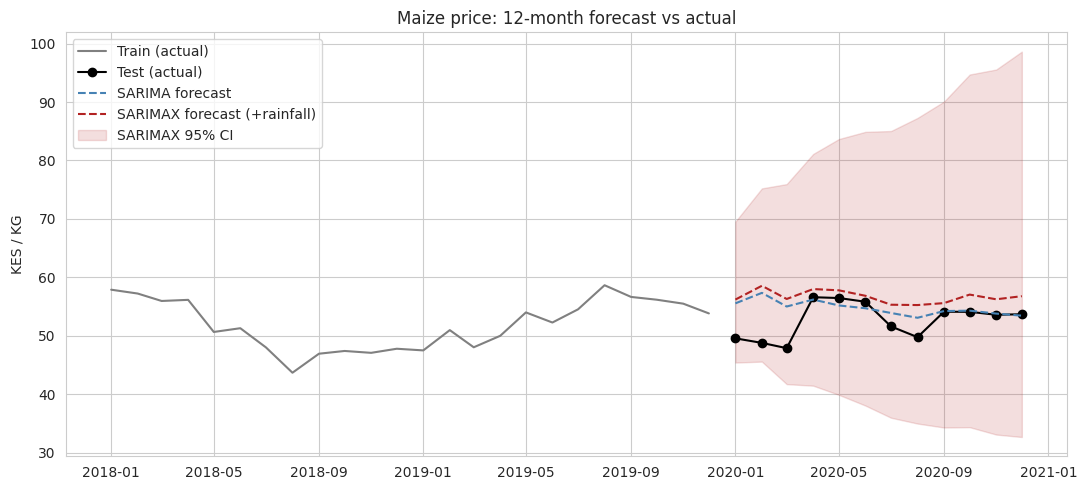

In [26]:
forecast_sarima = fit_sarima.get_forecast(steps=n_test)
forecast_sarimax = fit_sarimax.get_forecast(steps=n_test, exog=test_rain)

pred_sarima = forecast_sarima.predicted_mean
pred_sarimax = forecast_sarimax.predicted_mean
ci_sarimax = forecast_sarimax.conf_int()

# Convert back from log scale to KES/KG for interpretability
actual_price_level = np.exp(test_price)
pred_sarima_level = np.exp(pred_sarima)
pred_sarimax_level = np.exp(pred_sarimax)
ci_sarimax_level = np.exp(ci_sarimax)

plt.figure(figsize=(11, 5))
plt.plot(np.exp(train_price.iloc[-24:]), label="Train (actual)", color="gray")
plt.plot(actual_price_level, label="Test (actual)", color="black", marker="o")
plt.plot(pred_sarima_level, label="SARIMA forecast", color="steelblue", linestyle="--")
plt.plot(pred_sarimax_level, label="SARIMAX forecast (+rainfall)", color="firebrick", linestyle="--")
plt.fill_between(ci_sarimax_level.index,
                  ci_sarimax_level.iloc[:, 0],
                  ci_sarimax_level.iloc[:, 1],
                  color="firebrick", alpha=0.15, label="SARIMAX 95% CI")
plt.title("Maize price: 12-month forecast vs actual")
plt.ylabel("KES / KG")
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def rmse(a, b):
    return np.sqrt(mean_squared_error(a, b))

print("Evaluation on held-out 12 months (KES/KG scale):")
print(f"  SARIMA  — MAE: {mean_absolute_error(actual_price_level, pred_sarima_level):.2f}   RMSE: {rmse(actual_price_level, pred_sarima_level):.2f}")
print(f"  SARIMAX — MAE: {mean_absolute_error(actual_price_level, pred_sarimax_level):.2f}   RMSE: {rmse(actual_price_level, pred_sarimax_level):.2f}")

Evaluation on held-out 12 months (KES/KG scale):
  SARIMA  — MAE: 2.57   RMSE: 3.86
  SARIMAX — MAE: 3.99   RMSE: 4.88


**Interpreting this:**
- Compare AIC and out-of-sample MAE/RMSE between the two models. If SARIMAX (with rainfall) doesn't clearly beat plain SARIMA, it may be because rainfall affects price with a **lag** (e.g. 3–6 months, tied to harvest timing) rather than the same month — worth testing `rain_ts.shift(k)` as the exogenous variable for a few different lags `k`.
- 12 months is a short test window; results can be noisy. Consider walk-forward validation (refit and forecast 1 step at a time, rolling through more of the history) for a more robust comparison.
- This order `(1,1,1)(1,1,0,12)` is a starting point, not a tuned model — grid-search over `(p,d,q)(P,D,Q,12)` combinations by AIC, or use `pmdarima.auto_arima(train_price, seasonal=True, m=12)` if you install `pmdarima`.

---
# Crop Yield / Long-Term Trends (placeholder)

No yield dataset has been provided yet. Once one is available (e.g. tonnes/hectare by year and region), the same workflow applies directly:

1. Convert to a time series (likely annual rather than monthly, given how yield data is usually reported)
2. Plot and visually inspect for trend
3. Rolling statistics (a shorter window, e.g. 3–5 years, given annual frequency)
4. ADF test
5. Transform if needed (yield trends are often closer to linear than exponential, so differencing alone — without a log transform — may be enough)
6. Plot the transformed series
7. Re-run ADF

Given the annual frequency, this series will have far fewer observations than the monthly price/rainfall series, which limits how complex a model (e.g. SARIMA seasonal order) can reliably be fit — a simple trend + ARIMA(p,d,q) on annual data, or even a Mann-Kendall trend test, may be more appropriate than a full seasonal model.